In [3]:
from google.colab import drive
import pandas as pd
import os

df32 = pd.read_csv('/content/1_CAM_32x32 - Sheet1-7.csv', nrows=19)
df64 = pd.read_csv('/content/1_CAM_64x64 - Sheet1-7.csv', nrows=19)
df96 = pd.read_csv('/content/1_CAM_96x96 - Sheet1-7.csv', nrows=19)
df128 = pd.read_csv('/content/1_CAM_128x128 - Sheet1-7.csv', nrows=19)


# df_spatten_energygain = pd.read_csv('/content/data_spatten_over_others_energy - Sheet1.csv')
# df_spatten_speedup = pd.read_csv('/content/data_spatten_over_others_latency - Sheet1.csv')

# Create the new DataFrame
area_power_df = pd.DataFrame({
    'size': [32, 64, 96, 128],
    'area': [
        df32["Area mm2.1"].sum(),
        df64["Area mm2.1"].sum(),
        df96["Area mm2.1"].sum(),
        df128["Area mm2.1"].sum()
    ],
    'power': [
        df32["Power W.1"].sum(),
        df64["Power W.1"].sum(),
        df96["Power W.1"].sum(),
        df128["Power W.1"].sum()
    ]
})

# # Display the DataFrame
# print(area_power_df)

In [4]:
area_power_df

,size,area,power
0,32,2.205202,3.320468
1,64,2.310967,3.587114
2,96,2.451467,3.972414
3,128,2.566467,4.332814


In [5]:
df96

,Description,Genre,Unnamed: 2,Module,Cycle Count,Area um2,Area mm2,Power uW,Power mW,Power W,COUNT,Area mm2.1,Power W.1,Latency,Energy
0,NaN,Attention Score,a1_q_buffer,Q buffer,1.0,37171.200000,0.037200,69882.3,69.8823,0.069900,1.0,0.037200,0.069900,2.000000e-09,1.400000e-10
1,NaN,Attention Score,NaN,Key SRAM,1.0,NaN,1.051000,NaN,NaN,NaN,1.0,1.051000,NaN,NaN,2.193695e-06
2,NaN,Attention Score,a2_ML_REG,ML_REG,1.0,38342.400000,0.038300,72101.4,72.1014,0.072100,1.0,0.038300,0.072100,2.000000e-09,1.440000e-10
3,NaN,BA-CAM,NaN,96x96 CAM,1.0,30412.800000,0.030400,158000.0,158.0000,0.158000,1.0,0.030400,0.226800,2.000000e-09,4.540000e-10
4,NaN,BA-CAM,a3_input_buf,96x1 buf,1.0,1152.000000,0.001200,2174.4,2.1744,0.002200,1.0,0.001200,0.002200,2.000000e-09,4.350000e-12
5,NaN,BA-CAM,a4_11bit_adc,11bit ADC,1.0,855.300000,0.000900,1783.3,1.7833,0.001800,96.0,0.082100,0.170400,2.000000e-09,3.410000e-10
6,NaN,BA-CAM,a5_x8,x8,1.0,261.400000,0.000300,774.8,0.7748,0.000800,96.0,0.025100,0.074400,2.000000e-09,1.490000e-10
7,NaN,BA-CAM,a6_sub96,-CAMH subtractor,1.0,399.900000,0.000400,954.0,0.9540,0.001000,96.0,0.038400,0.091600,2.000000e-09,1.830000e-10
8,NaN,BA-CAM,a7_accum_array,ACCUM array,14.0,43181.300000,0.043200,67085.3,67.0853,0.067100,1.0,0.043200,0.067100,2.000000e-09,1.340000e-10
9,NaN,BA-CAM,a8_top3,Top3,87.0,7154.000000,0.007200,3841.5,3.8415,0.003800,1.0,0.007200,0.003800,2.000000e-09,7.680000e-12


In [6]:
def get_appropriate_df(size):
    if size == 32:
        return df32
    elif size == 64:
        return df64
    elif size == 96:
        return df96
    elif size == 128:
        return df128
    else:
        raise ValueError(f"Unsupported size: {size}")

def get_module_name(base_module, size):
    # Dictionary mapping base module names to their size-specific variants
    module_mappings = {
        "CAM": {
            32: "ML_REG",
            64: "ML_REG",
            96: "ML_REG",
            128: "ML_REG"
        },
        "buf": {
            32: "32x1 buf",
            64: "64x1 buf",
            96: "96x1 buf",
            128: "128x1 buf"
        },
        "ADC": {
            32: "9bit ADC",
            64: "10bit ADC",
            96: "11bit ADC",
            128: "11bit ADC"
        },
        "x8": {
            32: "x8",
            64: "x8",
            96: "x8",
            128: "x8"
        },
        "-CAMH subtractor": {
            32: "-CAMH subtractor",
            64: "-CAMH subtractor",
            96: "-CAMH subtractor",
            128: "-CAMH subtractor"
        },
        "ACCUM array": {
            32: "ACCUM array",
            64: "ACCUM array",
            96: "ACCUM array",
            128: "ACCUM array"
        },
        "Top3": {
            32: "Top3",
            64: "Top3",
            96: "Top3",
            128: "Top3"
        },
        "Convert": {
            32: "Convert",
            64: "Convert",
            96: "Convert",
            128: "Convert"
        },
        "Top30": {
            32: "Top30",
            64: "Top30",
            96: "Top30",
            128: "Top30"
        },
        "SoftMax": {
            32: "SoftMax",
            64: "SoftMax",
            96: "SoftMax",
            128: "SoftMax"
        },
        "Sparse MatMul": {
            32: "Sparse MatMul",
            64: "Sparse MatMul",
            96: "Sparse MatMul",
            128: "Sparse MatMul"
        }
    }

    if base_module not in module_mappings:
        raise ValueError(f"Unknown base module: {base_module}")

    if size not in module_mappings[base_module]:
        raise ValueError(f"Unsupported size {size} for module {base_module}")

    return module_mappings[base_module][size]

def cycle_finder(base_module, size):
    df = get_appropriate_df(size)
    module_name = get_module_name(base_module, size)

    try:
        cycle_count = df.loc[df["Module"] == module_name, "Cycle Count"].iloc[0]
        return cycle_count
    except (KeyError, IndexError):
        print(f"Available modules in df{size}:")
        print(df["Module"].unique())
        raise ValueError(f"Module '{module_name}' not found in dataframe for size {size}")

def total_cycle_count(k, n, dv, CAMH, CAMW):
    if CAMH != CAMW:
        raise ValueError("This implementation assumes CAMH equals CAMW")

    size = CAMH  # Using CAMH as the size since CAMH == CAMW
    tiling_count = (k/CAMW) * (n/CAMH)

    # Calculate the sum using the appropriate CAM size
    sum = 0

    # Basic operation cycles
    BA_CAM = (cycle_finder("CAM", size) +
              cycle_finder("buf", size) +
              cycle_finder("ADC", size) +
              cycle_finder("x8", size) +
              cycle_finder("-CAMH subtractor", size) +
              cycle_finder("ACCUM array", size))

    # Main computation
    sum = sum + BA_CAM * tiling_count + 1024/CAMH*(
        cycle_finder("Top3", size) +
        cycle_finder("Convert", size)
    )

    # Additional operations
    sum = sum + cycle_finder("Top30", size) + cycle_finder("SoftMax", size)

    sum = sum + cycle_finder("Sparse MatMul", size) + 3
    # sum = sum + cycle_finder("Top30", size) + cycle_finder("SoftMax", size)

    return sum

# Example usage with error handling
k = 1024
n = 1024
dv = 1024

sizing = 96
CAMH = sizing
CAMW = sizing

try:
    out = total_cycle_count(k=k, n=n, dv=dv, CAMH=CAMH, CAMW=CAMW)
    print(f"Total cycle count: {out}")
except ValueError as e:
    print(f"Error: {e}")

Total cycle count: 18589.444444444445


In [7]:

# Create the new DataFrame
area_power_latency_df = pd.DataFrame({
    'size': [32, 64, 96, 128],
    'area': [
        df32["Area mm2.1"].sum(),
        df64["Area mm2.1"].sum(),
        df96["Area mm2.1"].sum(),
        df128["Area mm2.1"].sum()
    ],
    'power': [
        df32["Power W.1"].sum(),
        df64["Power W.1"].sum(),
        df96["Power W.1"].sum(),
        df128["Power W.1"].sum()
    ],
    'latency': [
        total_cycle_count(k=1024, n=1024, dv=1024, CAMH=32, CAMW=32) * 2E-9,
        total_cycle_count(k=1024, n=1024, dv=1024, CAMH=64, CAMW=64) * 2E-9,
        total_cycle_count(k=1024, n=1024, dv=1024, CAMH=96, CAMW=96) * 2E-9,
        total_cycle_count(k=1024, n=1024, dv=1024, CAMH=128, CAMW=128) * 2E-9
    ]
})

# Display the DataFrame
print(area_power_latency_df)

# area_power_latency_df[area_power_latency_df[]]

   size      area     power   latency
0    32  2.205202  3.320468  0.000065
1    64  2.310967  3.587114  0.000042
2    96  2.451467  3.972414  0.000037
3   128  2.566467  4.332814  0.000035


In [ ]:
SpAtten_power = 8.30
SpAtten_area = 18.71

In [ ]:
sizing_choice = 32
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

sizing_choice = 64
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

sizing_choice = 96
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

sizing_choice = 128
max_num_cores = int(SpAtten_area/area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item())
print(max_num_cores)

2
2
2
2


In [ ]:
df_model_dims = pd.read_csv('/content/2_model max dimensions - Sheet1.csv')
df_model_dims["multiple"] = df_model_dims["m"] * df_model_dims["layer"]

# sizing_choice = 96
# core = 7

# df_model_dims["latency via CAMformer"] = df_model_dims["multiple"] *  area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["latency"].item() / core
# df_model_dims["area via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item() * core
# df_model_dims["power via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["power"].item()
# df_model_dims["energy via CAMformer"] = df_model_dims["power via CAMformer"] * df_model_dims["latency via CAMformer"]
# df_model_dims

def df_finder(sizing_choice, core_num):
   # Base metrics
   df_model_dims["latency via CAMformer"] = df_model_dims["multiple"] * area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["latency"].item() / core_num
   df_model_dims["area via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["area"].item() * core_num
   df_model_dims["power via CAMformer"] = area_power_latency_df[area_power_latency_df['size'] == sizing_choice]["power"].item()
   df_model_dims["energy via CAMformer"] = df_model_dims["power via CAMformer"] * df_model_dims["latency via CAMformer"] + 0.00704643

   # Calculate GOP based on the formula: GOPs = [(m × k × n) + (m × n × dv)] × layers / 1e9
   df_model_dims["GOP"] = ((df_model_dims["m"] * df_model_dims["k"] * df_model_dims["n"]* df_model_dims["n"]) +
                          (df_model_dims["m"] * df_model_dims["n"] * df_model_dims["n"]* df_model_dims["dv"])) * df_model_dims["layer"] / 1e9

   # Calculate GOP based on the formula: GOPs = [(m × k × n) + (m × n × dv)] × layers / 1e9
   df_model_dims["Eff. GOP"] = ((df_model_dims["m"] * df_model_dims["k"] * df_model_dims["n"]* df_model_dims["n"]) +
                          (df_model_dims["m"] * df_model_dims["n"] * 30 * df_model_dims["dv"])) * df_model_dims["layer"] / 1e9


   # Efficiency metrics
   df_model_dims["Throughput (GOP/s)"] = df_model_dims["GOP"] / df_model_dims["latency via CAMformer"]
   df_model_dims["Energy Efficiency (GOP/J)"] = df_model_dims["GOP"] / df_model_dims["energy via CAMformer"]
   df_model_dims["Energy Eff (GOP/W)"] = df_model_dims["Throughput (GOP/s)"] / df_model_dims["power via CAMformer"]
   df_model_dims["Area Efficiency (GOP/s/mm2)"] = df_model_dims["Throughput (GOP/s)"] / df_model_dims["area via CAMformer"]

   return df_model_dims

temp_df = df_finder(sizing_choice = 32, core_num = 1)
temp_df
# temp_df[temp_df['model'].str.contains("bert-large", case=False)]


,model,layer,m,n,k,dv,multiple,latency via CAMformer,area via CAMformer,power via CAMformer,energy via CAMformer,GOP,Eff. GOP,Throughput (GOP/s),Energy Efficiency (GOP/J),Energy Eff (GOP/W),Area Efficiency (GOP/s/mm2)
0,bert-base-squad-v2,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
1,bert-large-squad-v2,24,512,512,1024,1024,12288,0.443572,6.72611,3.304453,1.472810,6597.069767,3491.808412,14872.594382,4479.240079,4500.773327,2211.173231
2,bert-base-cola,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
3,bert-base-mnli-mm,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
4,bert-base-mnli-m,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
5,bert-base-mrpc,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
6,bert-base-qnli,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
7,bert-base-qqp,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
8,bert-base-rte,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923
9,bert-base-sst2,12,512,512,768,768,6144,0.221786,6.72611,3.304453,0.739928,2473.901162,1309.428154,11154.445786,3343.433921,3375.579995,1658.379923


In [ ]:
df_finder(sizing_choice = 32, core_num = )

SyntaxError: invalid syntax (<ipython-input-92-2dffcf4c9598>, line 1)

In [ ]:
df_A100 = pd.read_csv('/content/3_profiling_A100 - latency_power_energy_measurements.csv')
df_L40 = pd.read_csv('/content/3_profiling_L40 - latency_power_energy_measurements.csv')
df_titanxp = pd.read_csv('/content/3_profiling_titanxp - latency_power_energy_measurements.csv')


def calculate_efficiency_metrics(df_gpu, df_model_dims):
   """
   Calculate throughput and energy efficiency using model dimensions
   Sets GOPs to 0 if model not found in df_model_dims
   """
   # Make copy to avoid modifying original dataframe
   df = df_gpu.copy()

   # Convert latency to seconds
   df['latency(s)'] = df['latency(ms)'] / 1000

   # Calculate metrics for each model
   for index, row in df.iterrows():
       model_name = row['model']

       # Find corresponding model in df_model_dims
       matching_models = df_model_dims[df_model_dims['model'] == model_name]

       if len(matching_models) == 0:
           # If model not found, use 0 for GOPs
           gops = 0
           eff_gops = 0
       else:
           model_dims = matching_models.iloc[0]
           # Calculate GOPs
           gops = ((model_dims['m'] * model_dims['k'] * model_dims['n'] * model_dims['n']) +
                   (model_dims['m'] * model_dims['n'] * model_dims['n'] * model_dims['dv'] )) * model_dims['layer'] / 1e9

           eff_gops = ((model_dims['m'] * model_dims['k'] * model_dims['n'] * model_dims['n']) +
                   (model_dims['m'] * model_dims['n'] * 30 * model_dims['dv'] )) * model_dims['layer'] / 1e9



       # Calculate metrics
       df.loc[index, 'GOPs'] = gops
       df.loc[index, 'Eff. GOPs'] = eff_gops
       df.loc[index, 'Throughput (GOP/s)'] = gops / df.loc[index, 'latency(s)'] if gops != 0 else 0
       df.loc[index, 'Energy Efficiency (GOP/J)'] = gops / df.loc[index, 'energy(Joules)'] if gops != 0 else 0

   return df

# Process each GPU dataset
df_A100_metrics = calculate_efficiency_metrics(df_A100, df_model_dims)
df_L40_metrics = calculate_efficiency_metrics(df_L40, df_model_dims)
df_titanxp_metrics = calculate_efficiency_metrics(df_titanxp, df_model_dims)
df_titanxp_metrics

,model,latency(ms),dynamic power(Watts),energy(Joules),latency(s),GOPs,Eff. GOPs,Throughput (GOP/s),Energy Efficiency (GOP/J)
0,google/vit-base-patch16-224,4.226558,194.949875,0.823967,0.004227,140.919515,81.189670,3.334144e+04,171.025678
1,bert-base-cola,14.287604,185.384500,2.648700,0.014288,2473.901162,1309.428154,1.731502e+05,934.005800
2,gpt2-small-1bw,12.681725,181.739200,2.304767,0.012682,19791.209300,10185.514942,1.560609e+06,8587.075960
3,gpt2-small-ptb,12.715310,181.573525,2.308764,0.012715,19791.209300,10185.514942,1.556487e+06,8572.209762
4,gpt2-small-wikitext103,12.719091,181.524625,2.308828,0.012719,19791.209300,10185.514942,1.556024e+06,8571.972143
5,gpt2-small-wikitext2,13.028105,237.909825,3.099514,0.013028,19791.209300,10185.514942,1.519117e+06,6385.262109
6,gpt2-medium-1bw,44.575253,177.472750,7.910893,0.044575,52776.558133,27161.373180,1.183988e+06,6671.378077
7,gpt2-medium-ptb,44.665835,176.477875,7.882532,0.044666,52776.558133,27161.373180,1.181587e+06,6695.381399
8,gpt2-medium-wikitext103,44.660392,176.655675,7.889512,0.044660,52776.558133,27161.373180,1.181731e+06,6689.457869
9,gpt2-medium-wikitext2,44.667361,176.465750,7.882259,0.044667,52776.558133,27161.373180,1.181546e+06,6695.613292


# Cores study

In [ ]:
results = []
sizing_choices = [32, 64, 96, 128]  # adjust based on your actual choices
core_nums = [1, 2, 3, 4, 5, 6, 7]         # adjust based on your actual choices

for sizing_choice in sizing_choices:
    for core_num in core_nums:
        df = df_finder(sizing_choice=sizing_choice, core_num=core_num)

        # Look at each model's performance
        for idx, row in df.iterrows():
            model_name = row['model']
            throughput = row["Throughput (GOP/s)"]
            energy_eff = row["Energy Efficiency (GOP/J)"]
            area = row["area via CAMformer"]
            power = row["power via CAMformer"]
            area_eff = throughput / area  # GOP/s/mm²

            results.append({
                'Model': model_name,
                'Sizing': sizing_choice,
                'Cores': core_num,
                'Throughput': throughput,
                'Energy_Efficiency': energy_eff,
                'Area': area,
                'Power': power,
                'Area_Efficiency': area_eff
            })

result_df = pd.DataFrame(results)
print(result_df)

# Find models that perform well compared to baselines
promising_models = result_df[
    (result_df['Throughput'] > 360) &        # Better than MNNFast
    (result_df['Energy_Efficiency'] > 382) &  # Better than MNNFast
    (result_df['Area'] < 18.71)      # Better than A³
]

print("Models with good performance across all metrics:")
print(promising_models.sort_values(['Throughput', 'Energy_Efficiency', 'Area_Efficiency'],
                                 ascending=False)[['Model', 'Sizing', 'Cores',
                                                 'Throughput', 'Energy_Efficiency',
                                                 'Area']])
promising_models

                            Model  Sizing  Cores    Throughput  \
0              bert-base-squad-v2      32      1  1.115445e+04   
1             bert-large-squad-v2      32      1  1.487259e+04   
2                  bert-base-cola      32      1  1.115445e+04   
3               bert-base-mnli-mm      32      1  1.115445e+04   
4                bert-base-mnli-m      32      1  1.115445e+04   
..                            ...     ...    ...           ...   
555               gpt2-medium-ptb     128      7  2.236297e+06   
556       gpt2-medium-wikitext103     128      7  2.236297e+06   
557         gpt2-medium-wikitext2     128      7  2.236297e+06   
558   google/vit-base-patch16-224     128      7  6.207593e+04   
559  google/vit-large-patch32-384     128      7  4.483999e+04   

     Energy_Efficiency       Area     Power  Area_Efficiency  
0          3343.433921   6.726110  3.304453      1658.379923  
1          4479.240079   6.726110  3.304453      2211.173231  
2          3343.43

,Model,Sizing,Cores,Throughput,Energy_Efficiency,Area,Power,Area_Efficiency
0,bert-base-squad-v2,32,1,11154.445786,3343.433921,6.72611,3.304453,1658.379923
1,bert-large-squad-v2,32,1,14872.594382,4479.240079,6.72611,3.304453,2211.173231
2,bert-base-cola,32,1,11154.445786,3343.433921,6.72611,3.304453,1658.379923
3,bert-base-mnli-mm,32,1,11154.445786,3343.433921,6.72611,3.304453,1658.379923
4,bert-base-mnli-m,32,1,11154.445786,3343.433921,6.72611,3.304453,1658.379923
...,...,...,...,...,...,...,...,...
455,gpt2-medium-ptb,128,2,638941.876822,145144.616647,14.17475,4.316797,45076.060941
456,gpt2-medium-wikitext103,128,2,638941.876822,145144.616647,14.17475,4.316797,45076.060941
457,gpt2-medium-wikitext2,128,2,638941.876822,145144.616647,14.17475,4.316797,45076.060941
458,google/vit-base-patch16-224,128,2,17735.978578,3408.370469,14.17475,4.316797,1251.237523


# CAMformer vs GPUs

In [ ]:
# First, get all model names from each dataframe
models_camformer = set(df_finder(sizing_choice = 96, core_num = 2)['model'].tolist())
models_a100 = set(df_A100_metrics['model'].tolist())
models_l40 = set(df_L40_metrics['model'].tolist())
models_titanxp = set(df_titanxp_metrics['model'].tolist())

# Find common models across all four dataframes
common_models = models_camformer.intersection(models_a100, models_l40, models_titanxp)




listter = ['gpt2-medium-wikitext103', 'gpt2-small-wikitext103', 'bert-large-squad-v2', 'gpt2-medium-wikitext2', 'bert-base-mnli-mm', 'bert-base-qqp', 'gpt2-medium-1bw', 'gpt2-medium-ptb', 'bert-base-qnli', 'gpt2-small-1bw', 'bert-base-squad-v2', 'google/vit-base-patch16-224', 'gpt2-small-ptb', 'gpt2-small-wikitext2', 'bert-base-sst2', 'bert-base-cola', 'bert-base-mnli-m', 'bert-base-rte', 'bert-base-mrpc']
for i in range(len(listter)):
  print(listter[i])

gpt2-medium-wikitext103
gpt2-small-wikitext103
bert-large-squad-v2
gpt2-medium-wikitext2
bert-base-mnli-mm
bert-base-qqp
gpt2-medium-1bw
gpt2-medium-ptb
bert-base-qnli
gpt2-small-1bw
bert-base-squad-v2
google/vit-base-patch16-224
gpt2-small-ptb
gpt2-small-wikitext2
bert-base-sst2
bert-base-cola
bert-base-mnli-m
bert-base-rte
bert-base-mrpc


gpt2-medium-wikitext103


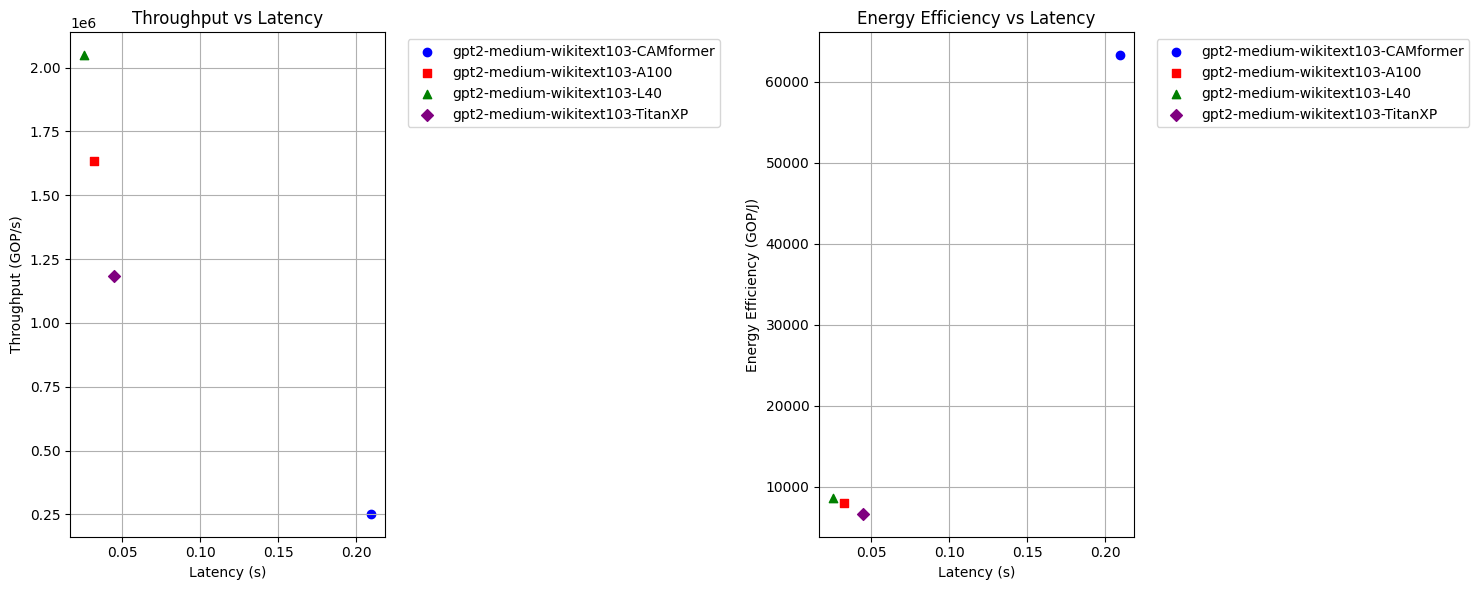

gpt2-small-wikitext103


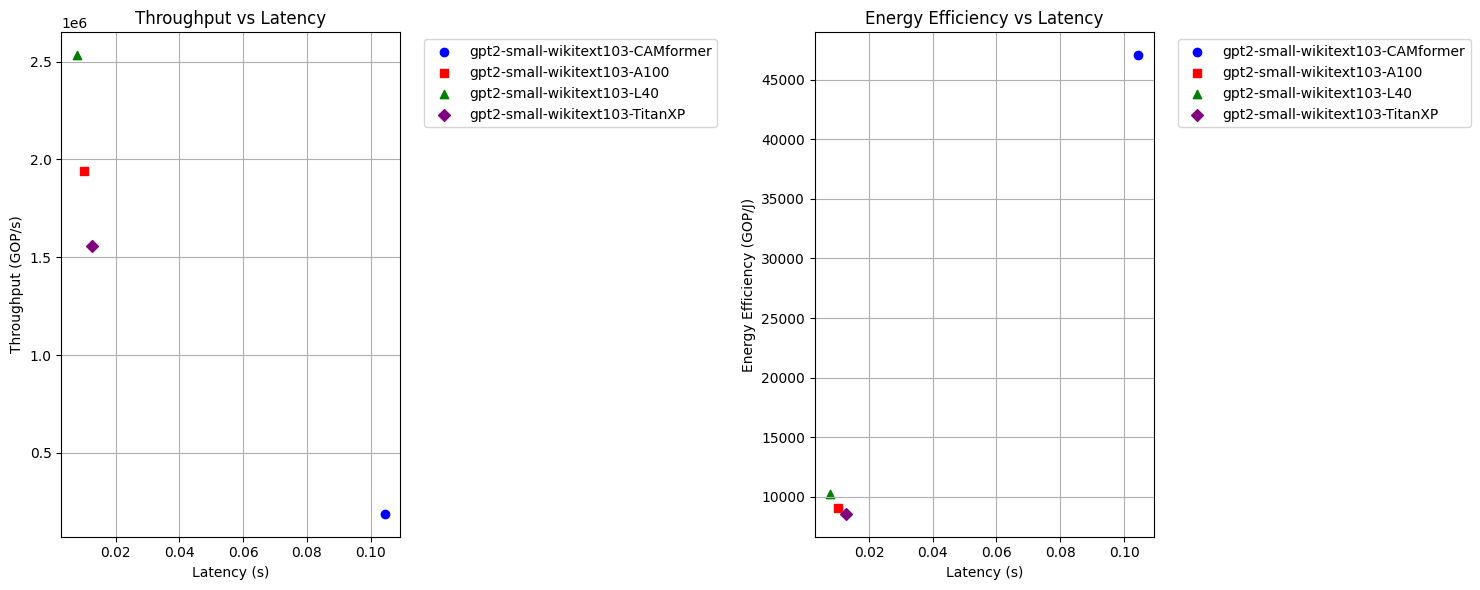

bert-large-squad-v2


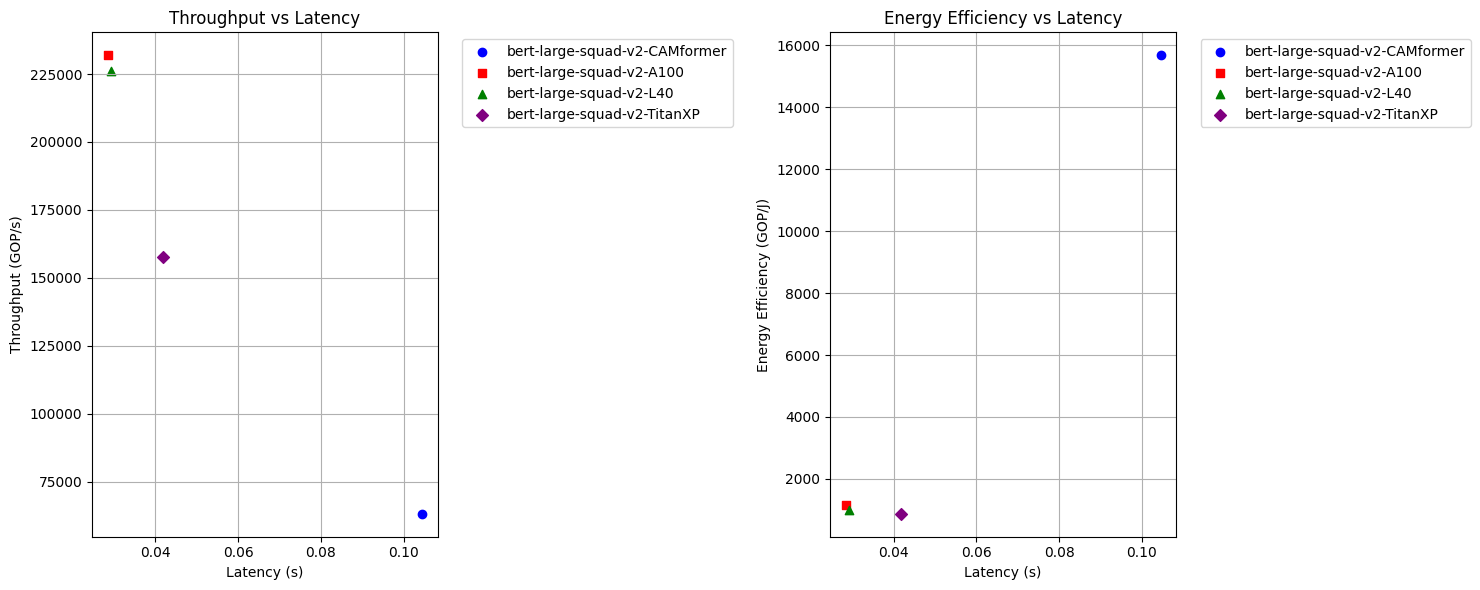

gpt2-medium-wikitext2


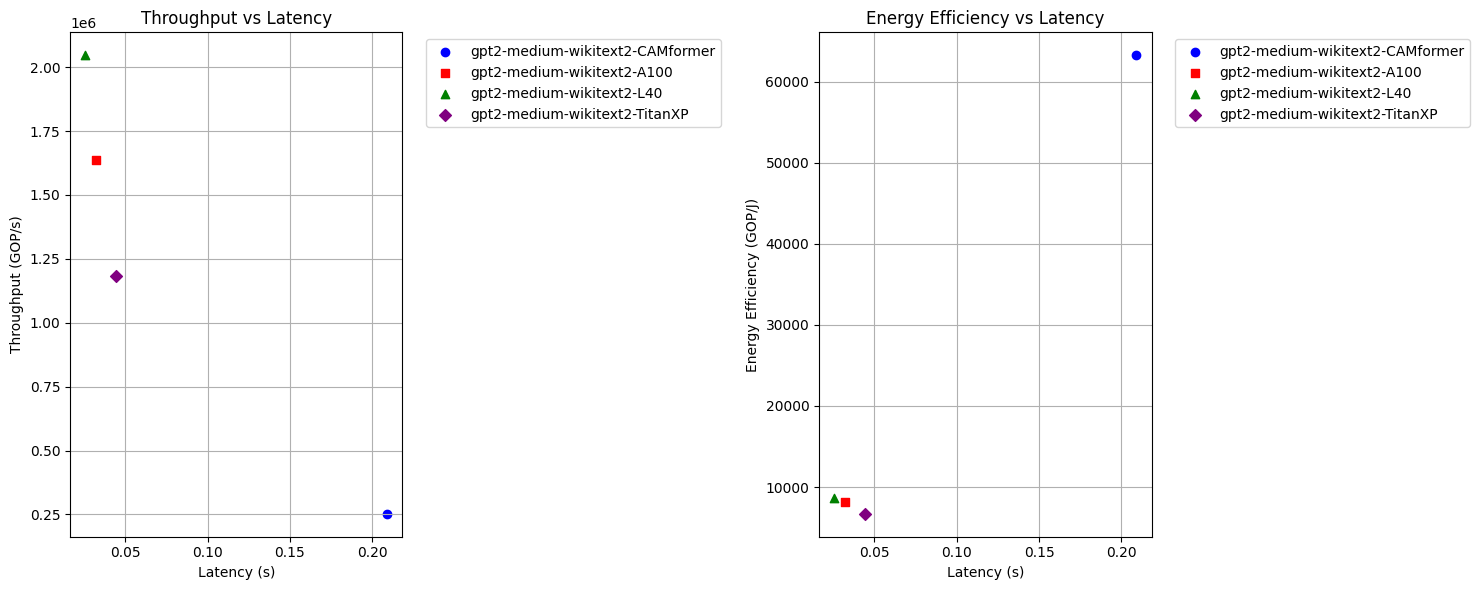

bert-base-mnli-mm


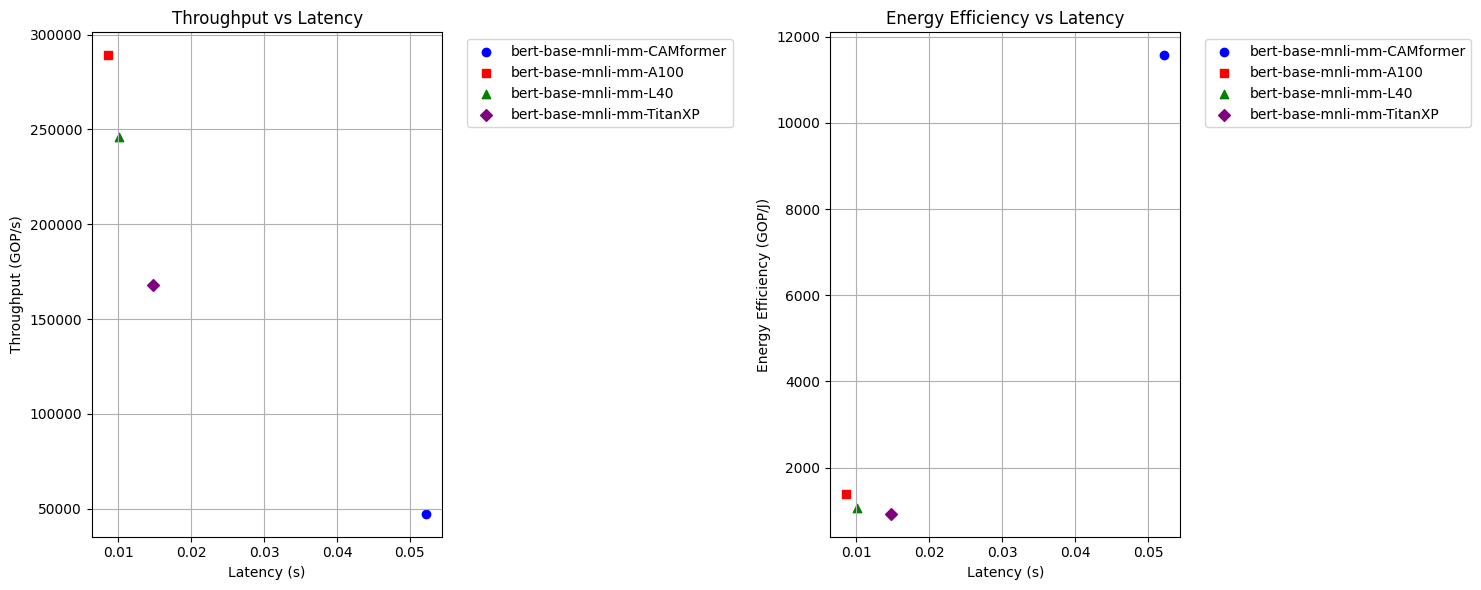

bert-base-qqp


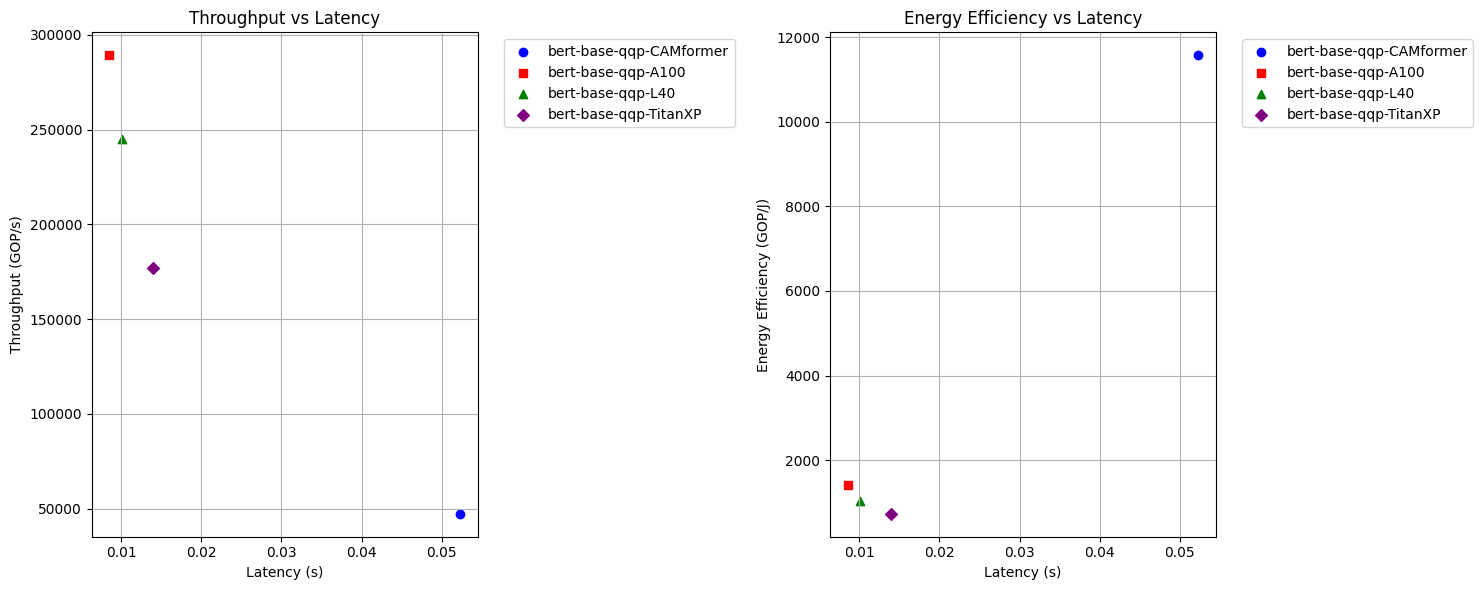

gpt2-medium-1bw


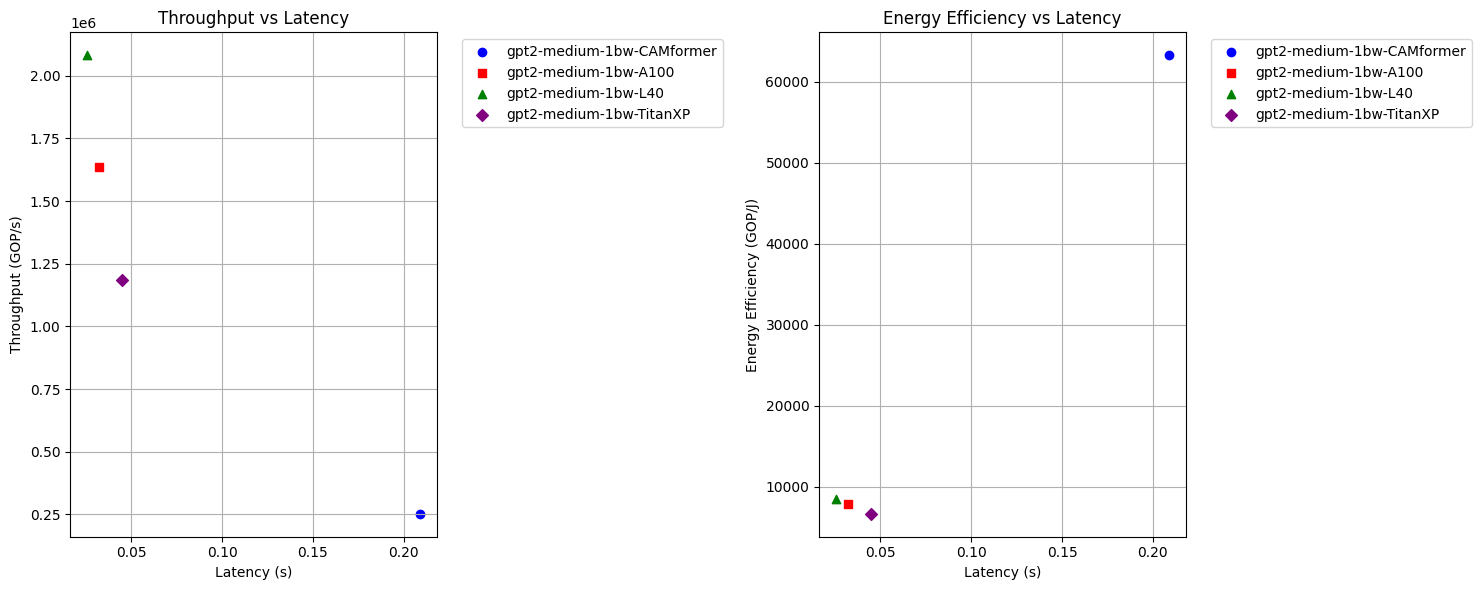

gpt2-medium-ptb


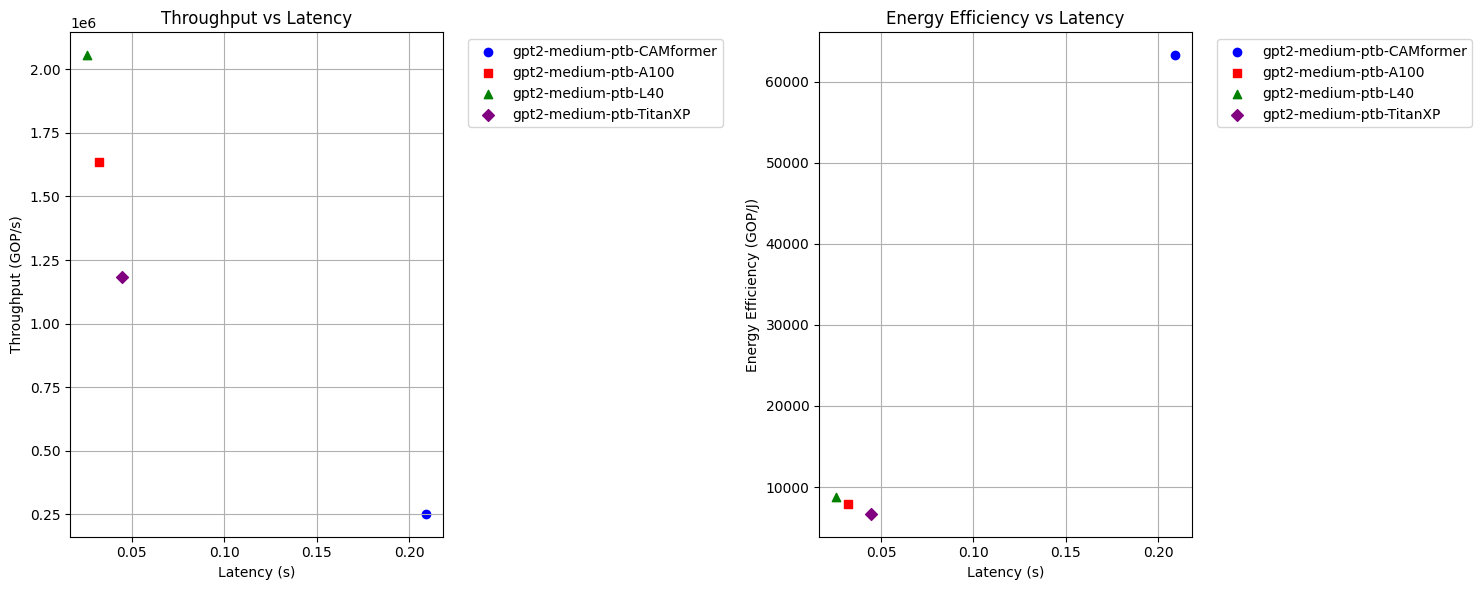

bert-base-qnli


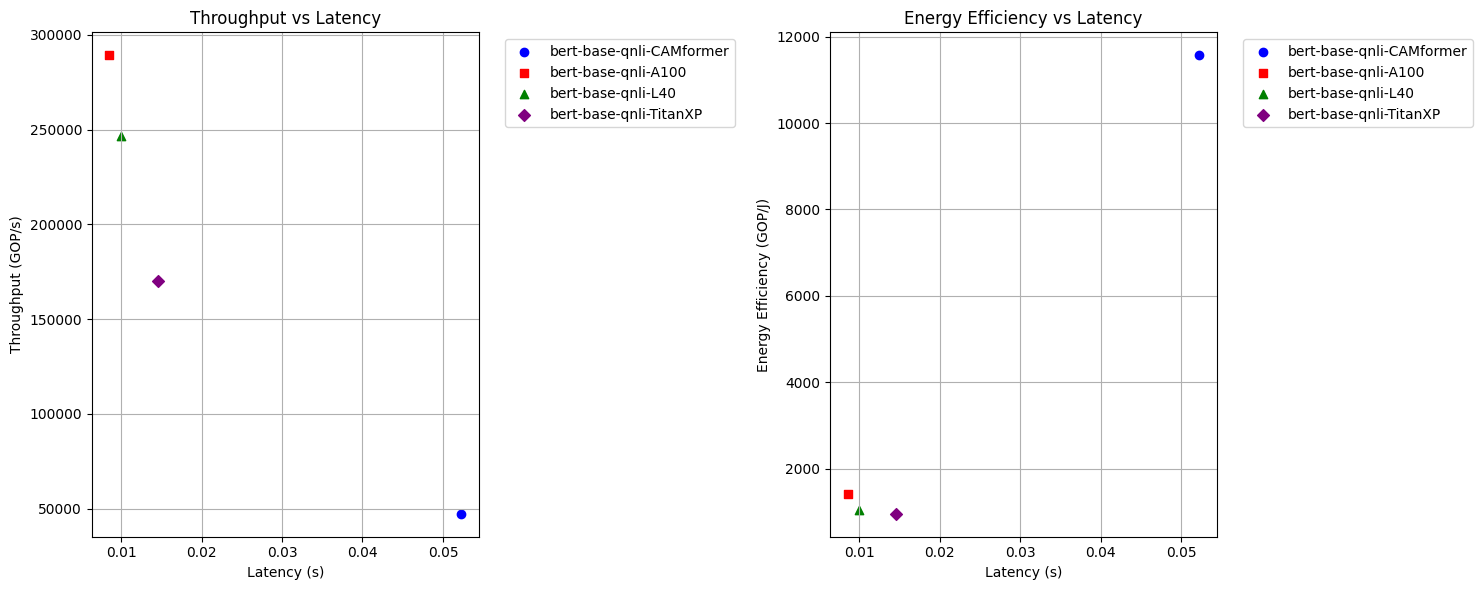

gpt2-small-1bw


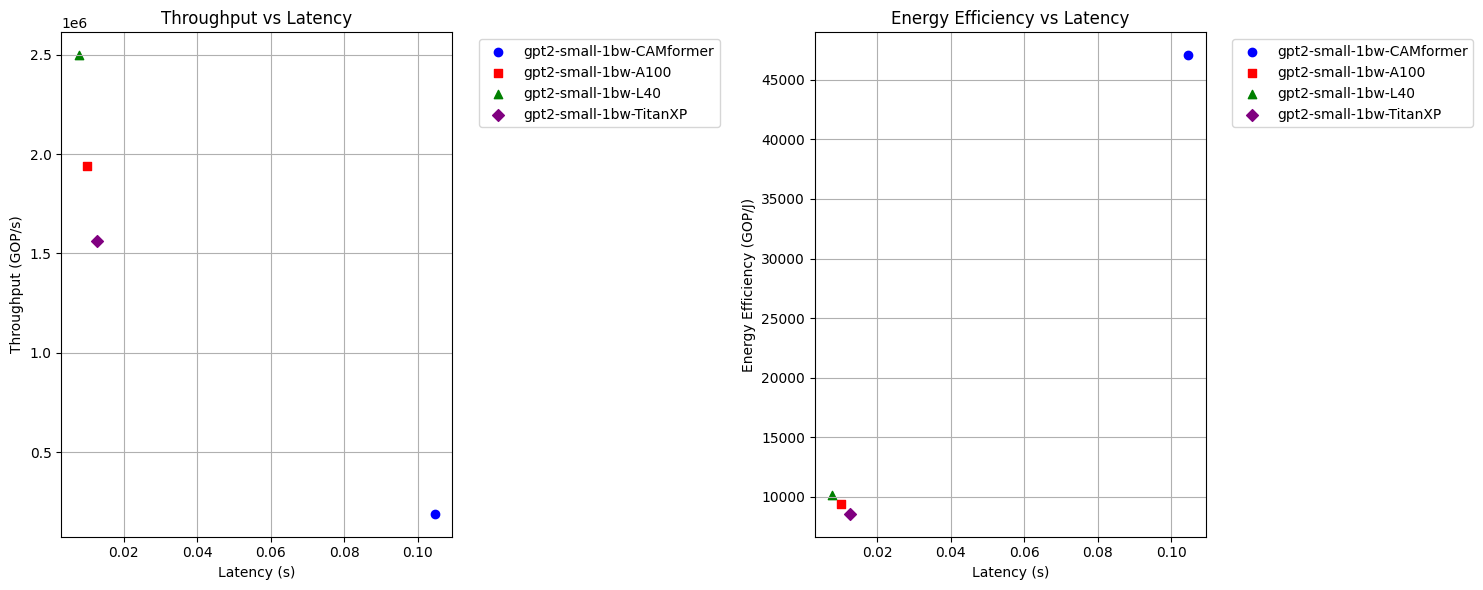

bert-base-squad-v2


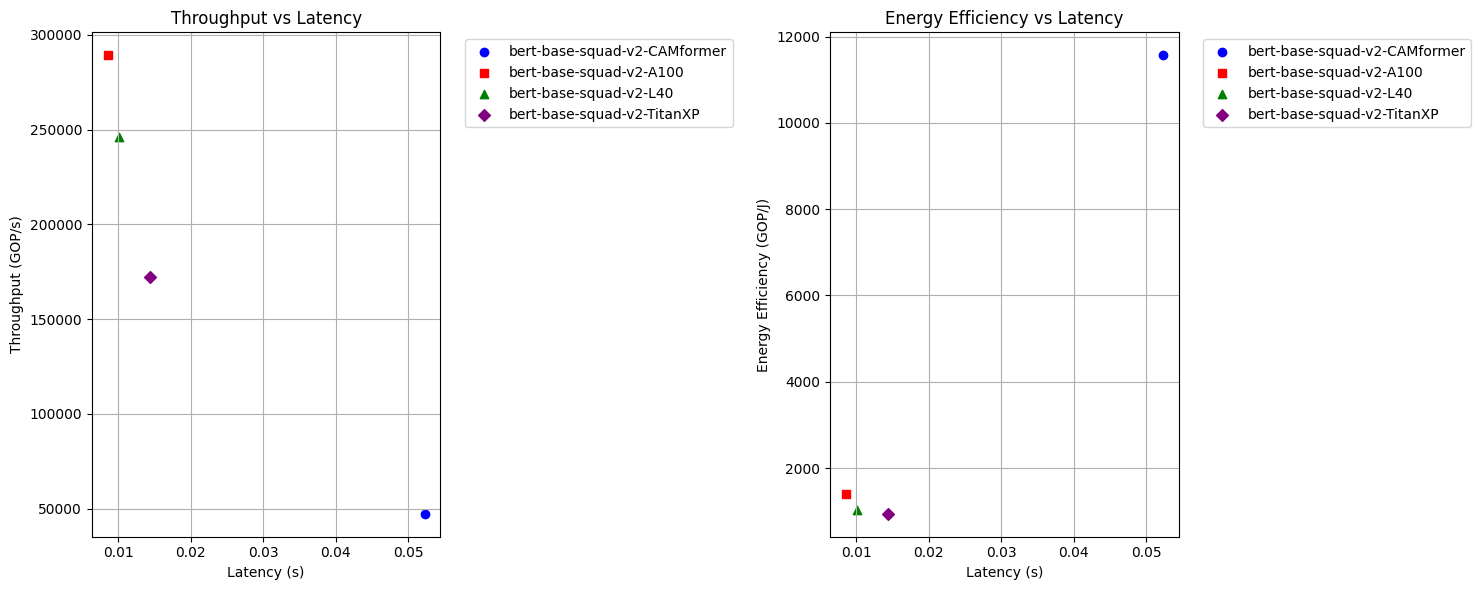

google/vit-base-patch16-224


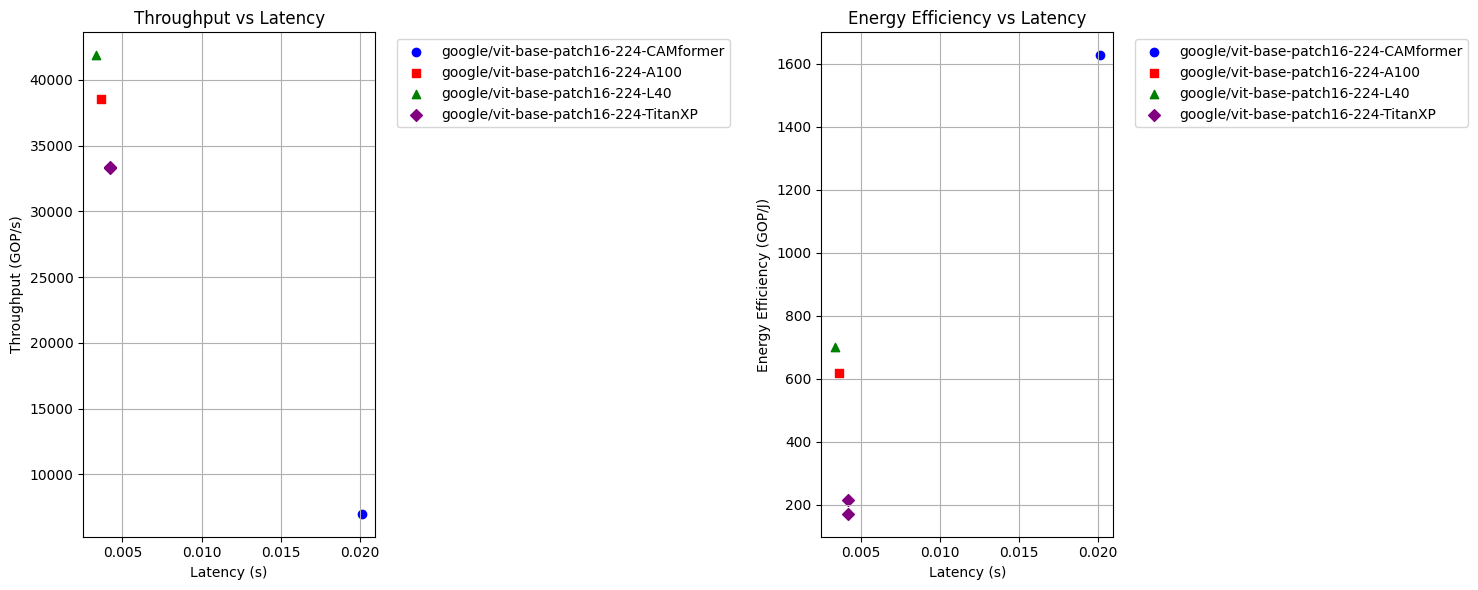

gpt2-small-ptb


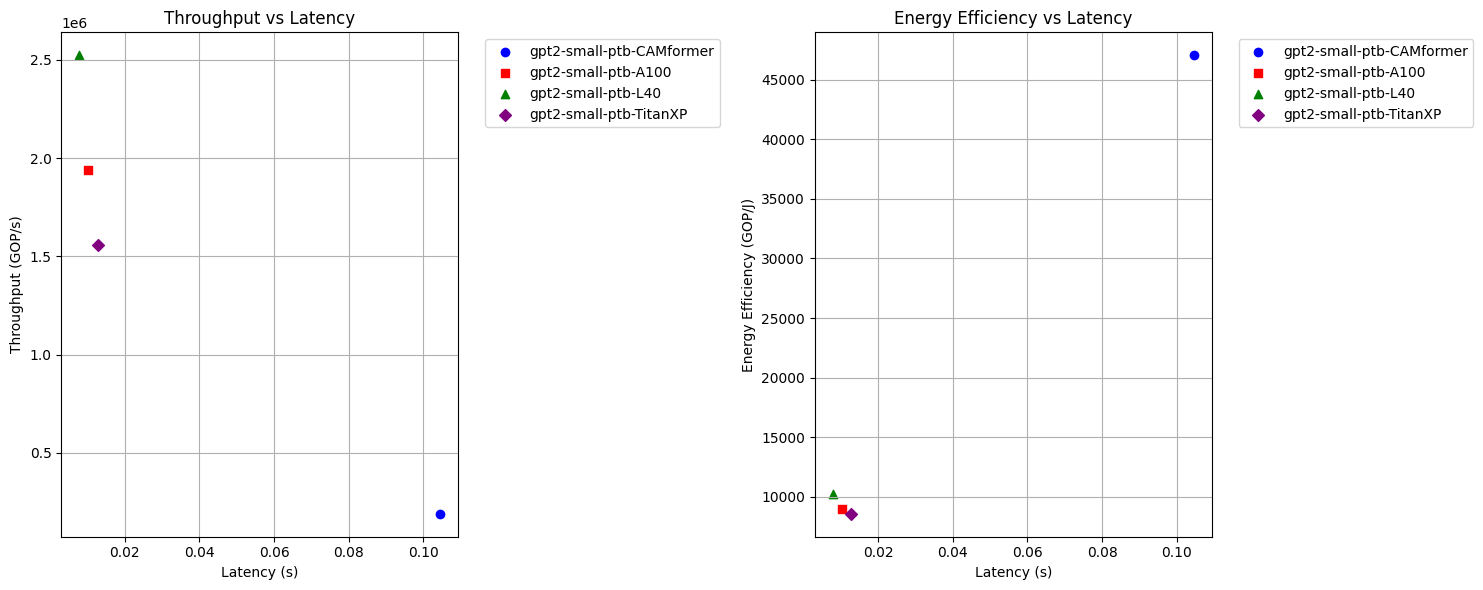

gpt2-small-wikitext2


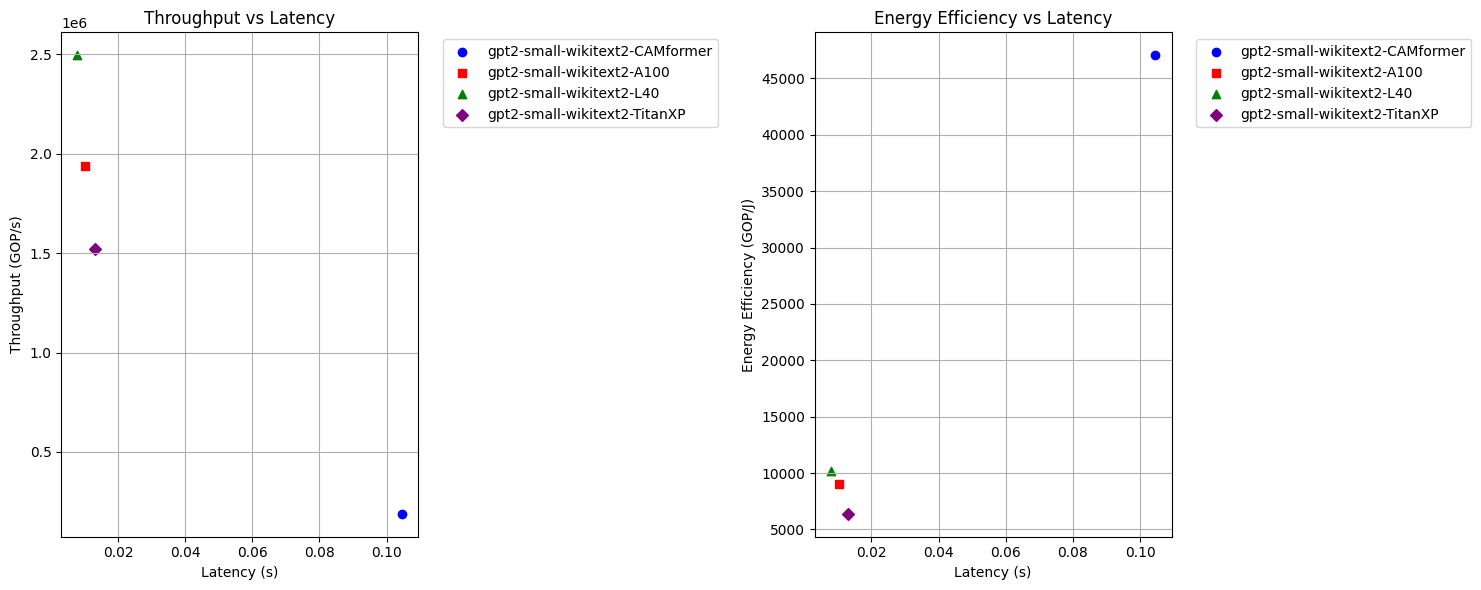

bert-base-sst2


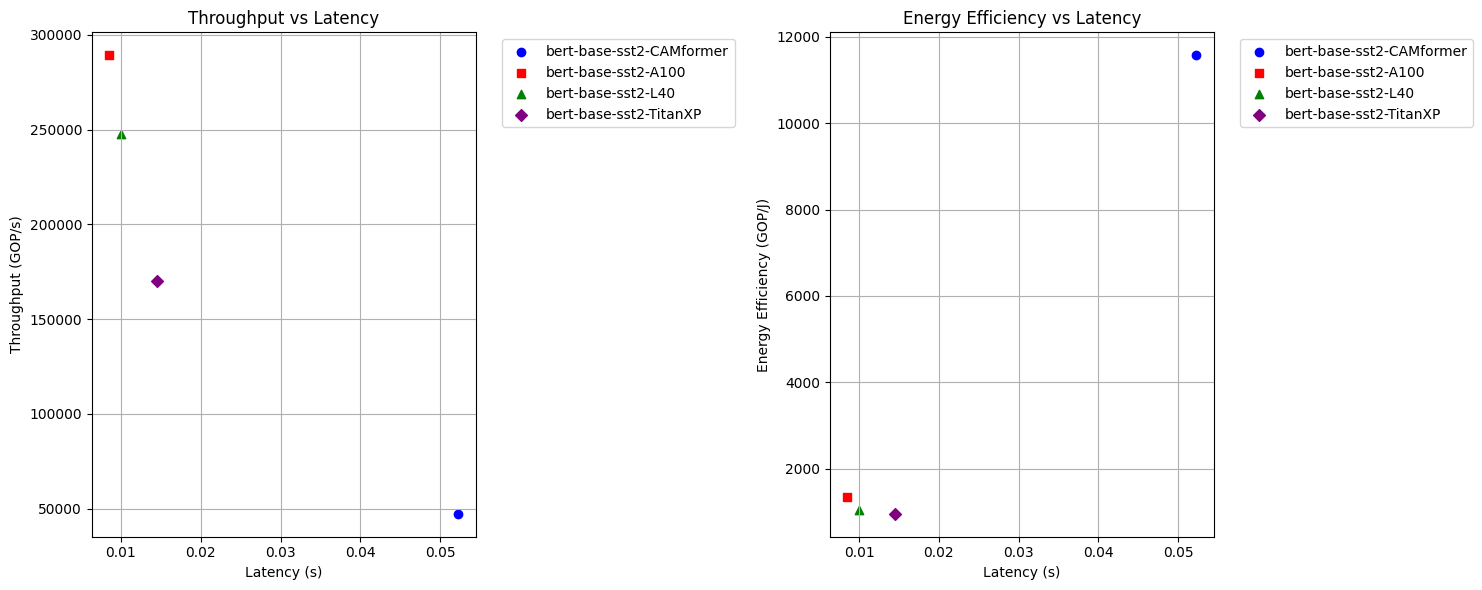

bert-base-cola


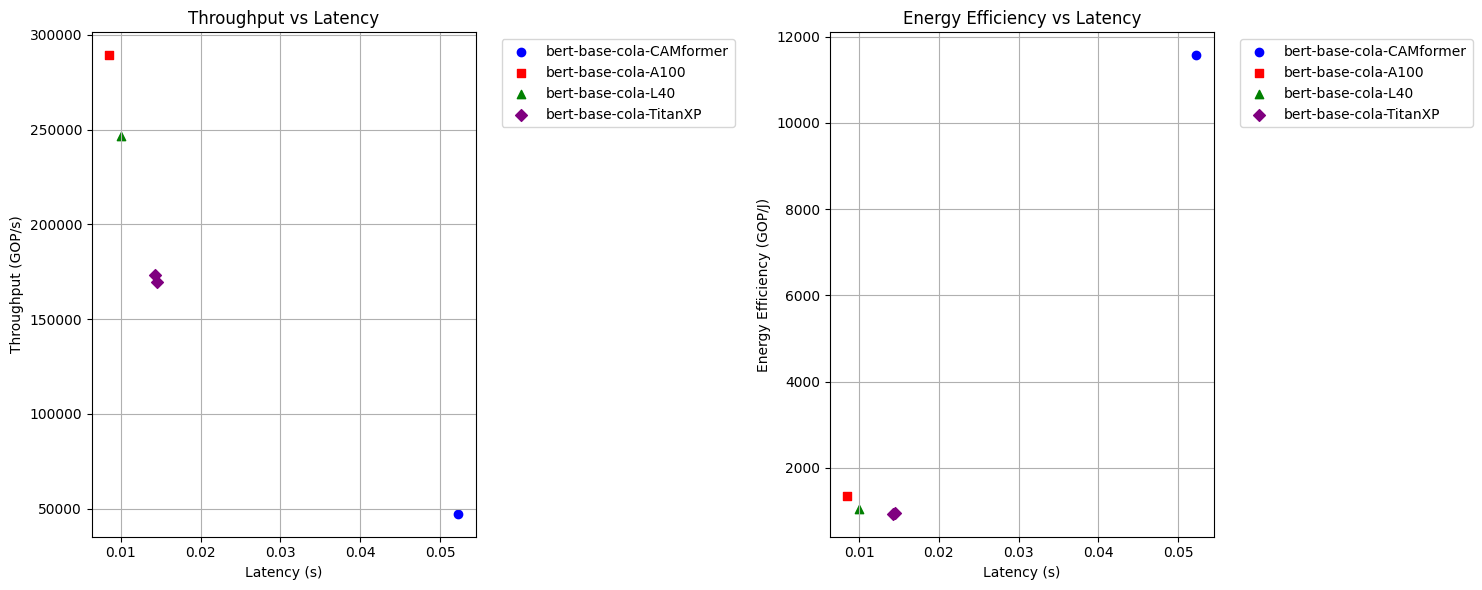

bert-base-mnli-m


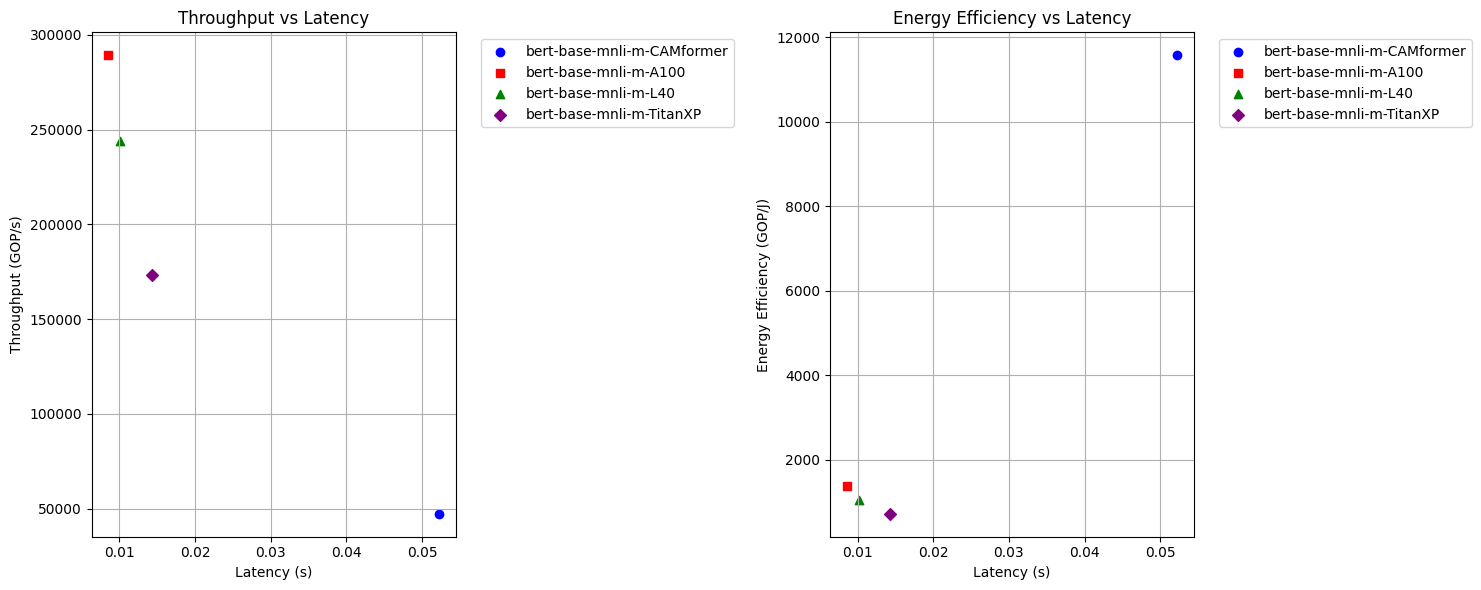

bert-base-rte


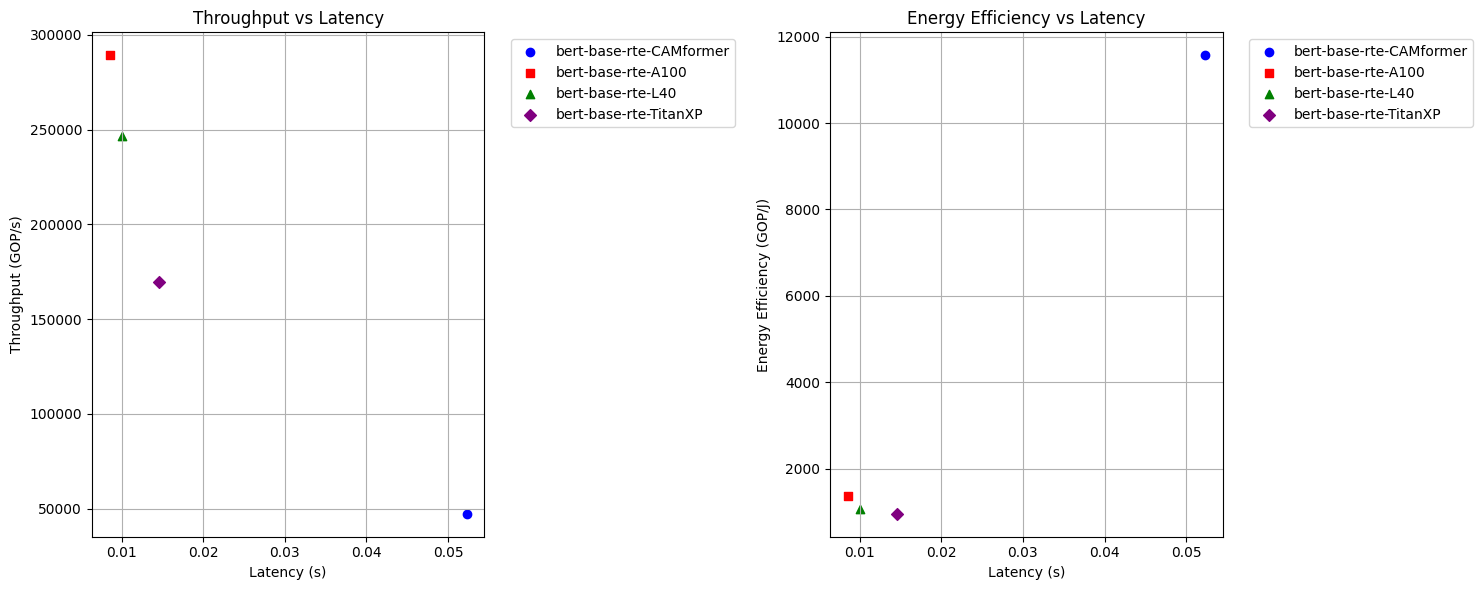

bert-base-mrpc


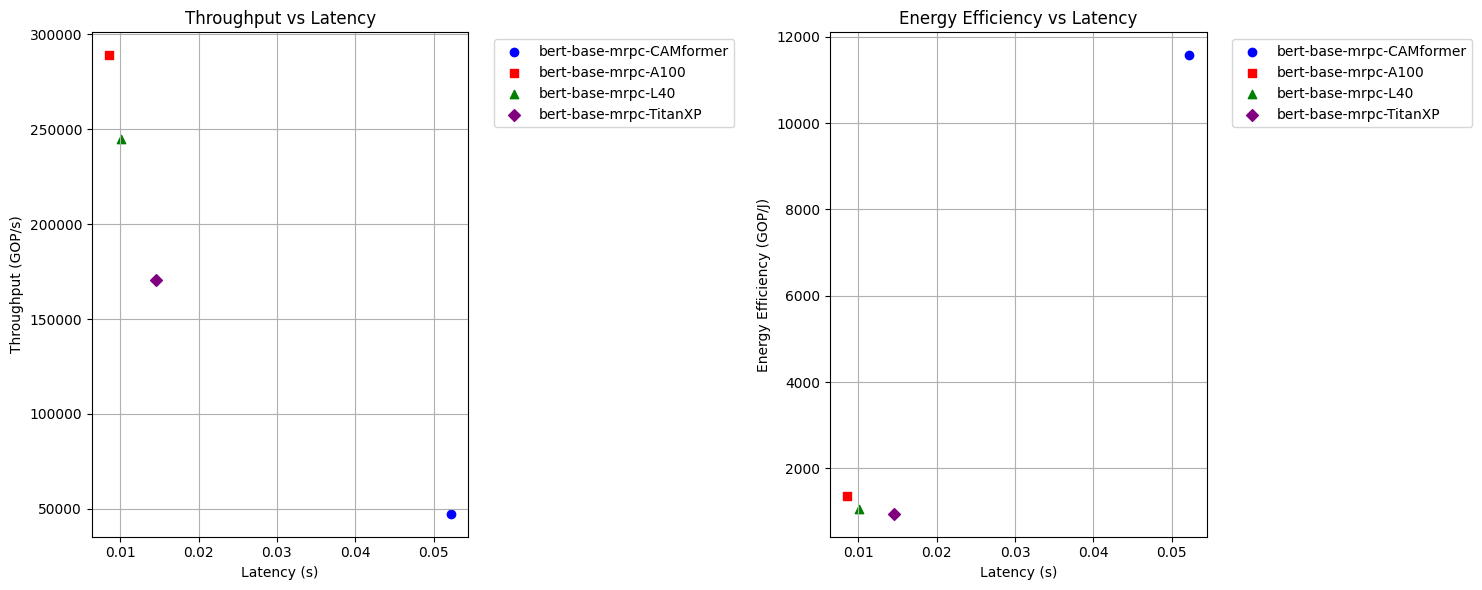

In [ ]:


# Let's create a plotting function for selected models
def plot_performance_metrics(models_to_plot, df_cam, df_a100, df_l40, df_titanxp):
   """
   Create two plots: Throughput vs Latency and Energy Efficiency vs Latency
   for selected models across different platforms
   """
   import matplotlib.pyplot as plt

   # Create figure with two subplots
   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

   # Colors and markers for different platforms
   platforms = {
       'CAMformer': {'color': 'blue', 'marker': 'o'},
       'A100': {'color': 'red', 'marker': 's'},
       'L40': {'color': 'green', 'marker': '^'},
       'TitanXP': {'color': 'purple', 'marker': 'D'}
   }

   # Plot for each model
   for model in models_to_plot:
       # Get data points for each platform
       cam_data = df_cam[df_cam['model'] == model]
       #print(cam_data)
       a100_data = df_a100[df_a100['model'] == model]
       l40_data = df_l40[df_l40['model'] == model]
       titan_data = df_titanxp[df_titanxp['model'] == model]

       # Throughput vs Latency
       ax1.scatter(cam_data['latency via CAMformer'], cam_data['Throughput (GOP/s)'],
                  label=f'{model}-CAMformer', **platforms['CAMformer'])
       ax1.scatter(a100_data['latency(s)'], a100_data['Throughput (GOP/s)'],
                  label=f'{model}-A100', **platforms['A100'])
       ax1.scatter(l40_data['latency(s)'], l40_data['Throughput (GOP/s)'],
                  label=f'{model}-L40', **platforms['L40'])
       ax1.scatter(titan_data['latency(s)'], titan_data['Throughput (GOP/s)'],
                  label=f'{model}-TitanXP', **platforms['TitanXP'])

       # Energy Efficiency vs Latency
       ax2.scatter(cam_data['latency via CAMformer'], cam_data['Energy Efficiency (GOP/J)'],
                  label=f'{model}-CAMformer', **platforms['CAMformer'])
       ax2.scatter(a100_data['latency(s)'], a100_data['Energy Efficiency (GOP/J)'],
                  label=f'{model}-A100', **platforms['A100'])
       ax2.scatter(l40_data['latency(s)'], l40_data['Energy Efficiency (GOP/J)'],
                  label=f'{model}-L40', **platforms['L40'])
       ax2.scatter(titan_data['latency(s)'], titan_data['Energy Efficiency (GOP/J)'],
                  label=f'{model}-TitanXP', **platforms['TitanXP'])

   # Configure first plot
   ax1.set_xlabel('Latency (s)')
   ax1.set_ylabel('Throughput (GOP/s)')
   ax1.set_title('Throughput vs Latency')
   ax1.grid(True)
   ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

   # Configure second plot
   ax2.set_xlabel('Latency (s)')
   ax2.set_ylabel('Energy Efficiency (GOP/J)')
   ax2.set_title('Energy Efficiency vs Latency')
   ax2.grid(True)
   ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

   plt.tight_layout()
   plt.show()

# Example usage - replace with your chosen models
selected_models = ['bert-base-rte']


# gpt2-medium-wikitext103
# gpt2-small-wikitext103
# bert-large-squad-v2
# gpt2-medium-wikitext2
# bert-base-mnli-mm
# bert-base-qqp
# gpt2-medium-1bw
# gpt2-medium-ptb
# bert-base-qnli
# gpt2-small-1bw
# bert-base-squad-v2
# google/vit-base-patch16-224
# gpt2-small-ptb
# gpt2-small-wikitext2
# bert-base-sst2
# bert-base-cola
# bert-base-mnli-m
# bert-base-rte
# bert-base-mrpc

# selected_models = listter  # Replace with models you want to plot
for selected_model in  listter:
  print(selected_model)
  modelist = [selected_model]
  plot_performance_metrics(modelist, df_finder(sizing_choice = 96, core_num = 1), df_A100_metrics, df_L40_metrics, df_titanxp_metrics)

# Pie chart

['Q buffer', 'Key SRAM', 'ML_REG', '96x96 CAM', '96x1 buf', '11bit ADC', 'x8', '-CAMH subtractor', 'ACCUM array', 'Top3', 'Convert', 'Top30', 'SoftMax', 'Sparse MatMul', 'Value SRAM', 'FP32 Accum', 0, 0, 0]

Area Labels: ['Key SRAM', 'Sparse MatMul', 'Value SRAM', 'Others']
Area Percentages: ['15.07%', '66.98%', '13.12%', '4.82%']

Power Labels: ['96x96 CAM', '11bit ADC', 'Sparse MatMul', 'Others']
Power Percentages: ['5.73%', '4.31%', '79.11%', '10.85%']
[1.051, 4.67, 0.915, 0.336374800291]
[0.2268, 0.1704, 3.13, 0.42919730000000006]
['Key SRAM', 'Sparse MatMul', 'Value SRAM', 'Others']
[15.073773715608851, 66.97861394090708, 13.123218791419697, 4.82439355206437]
[5.7324879885040865, 4.306948647447515, 79.11237832459344, 10.848185039454963]


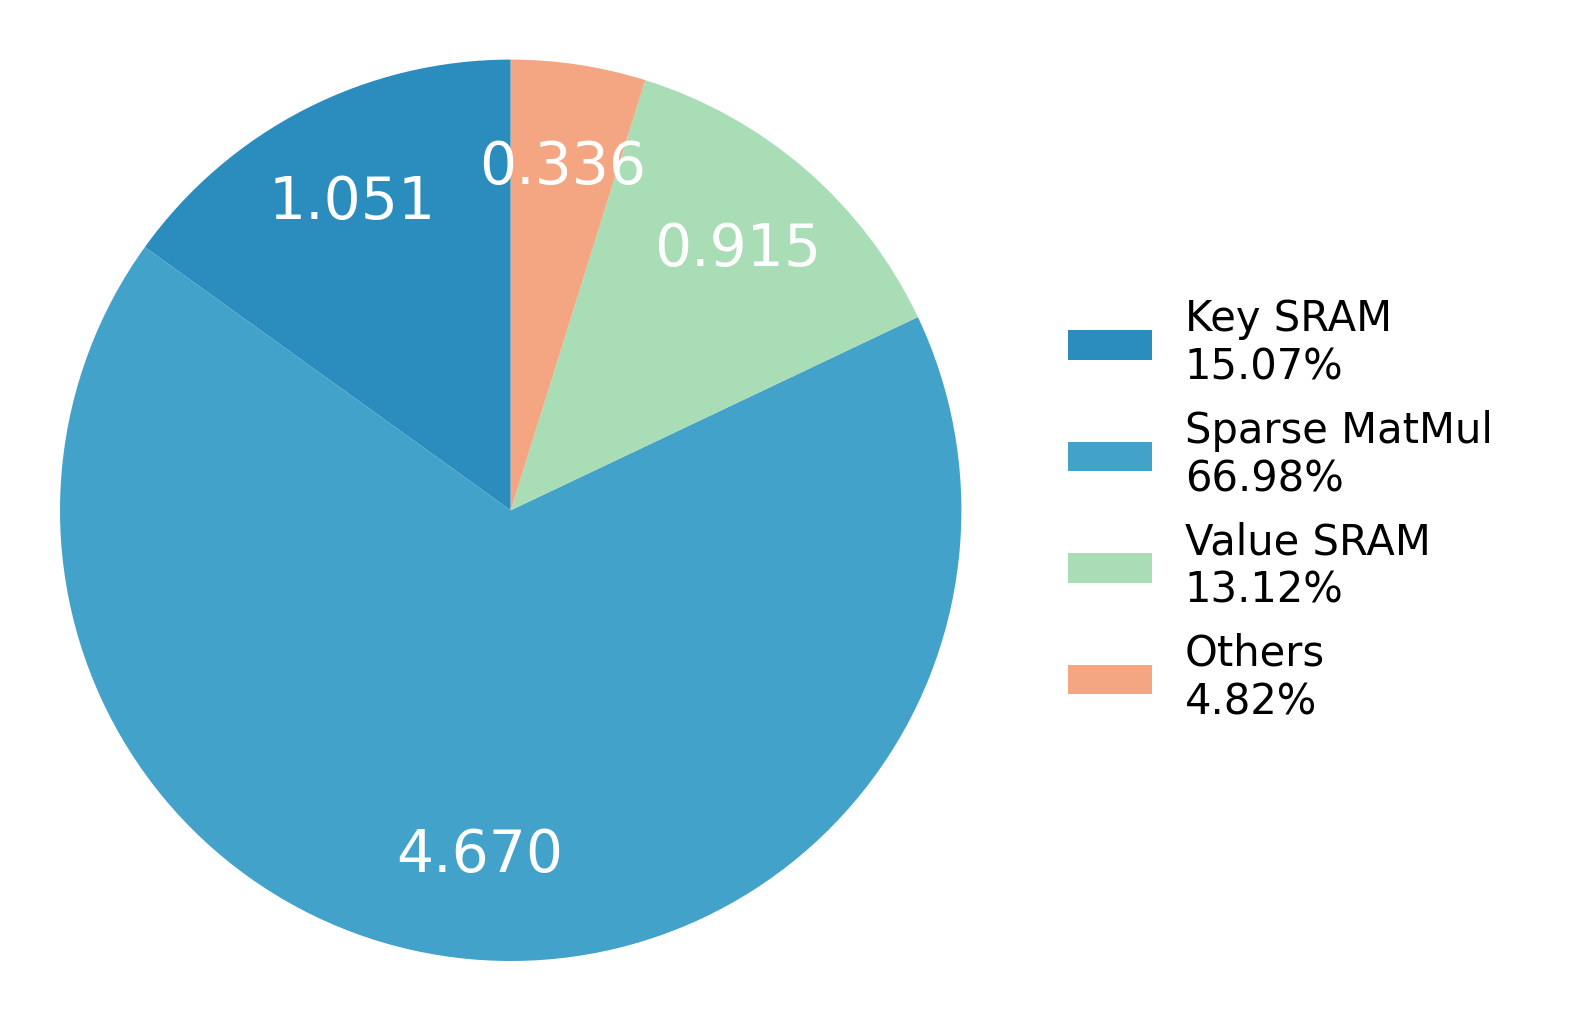

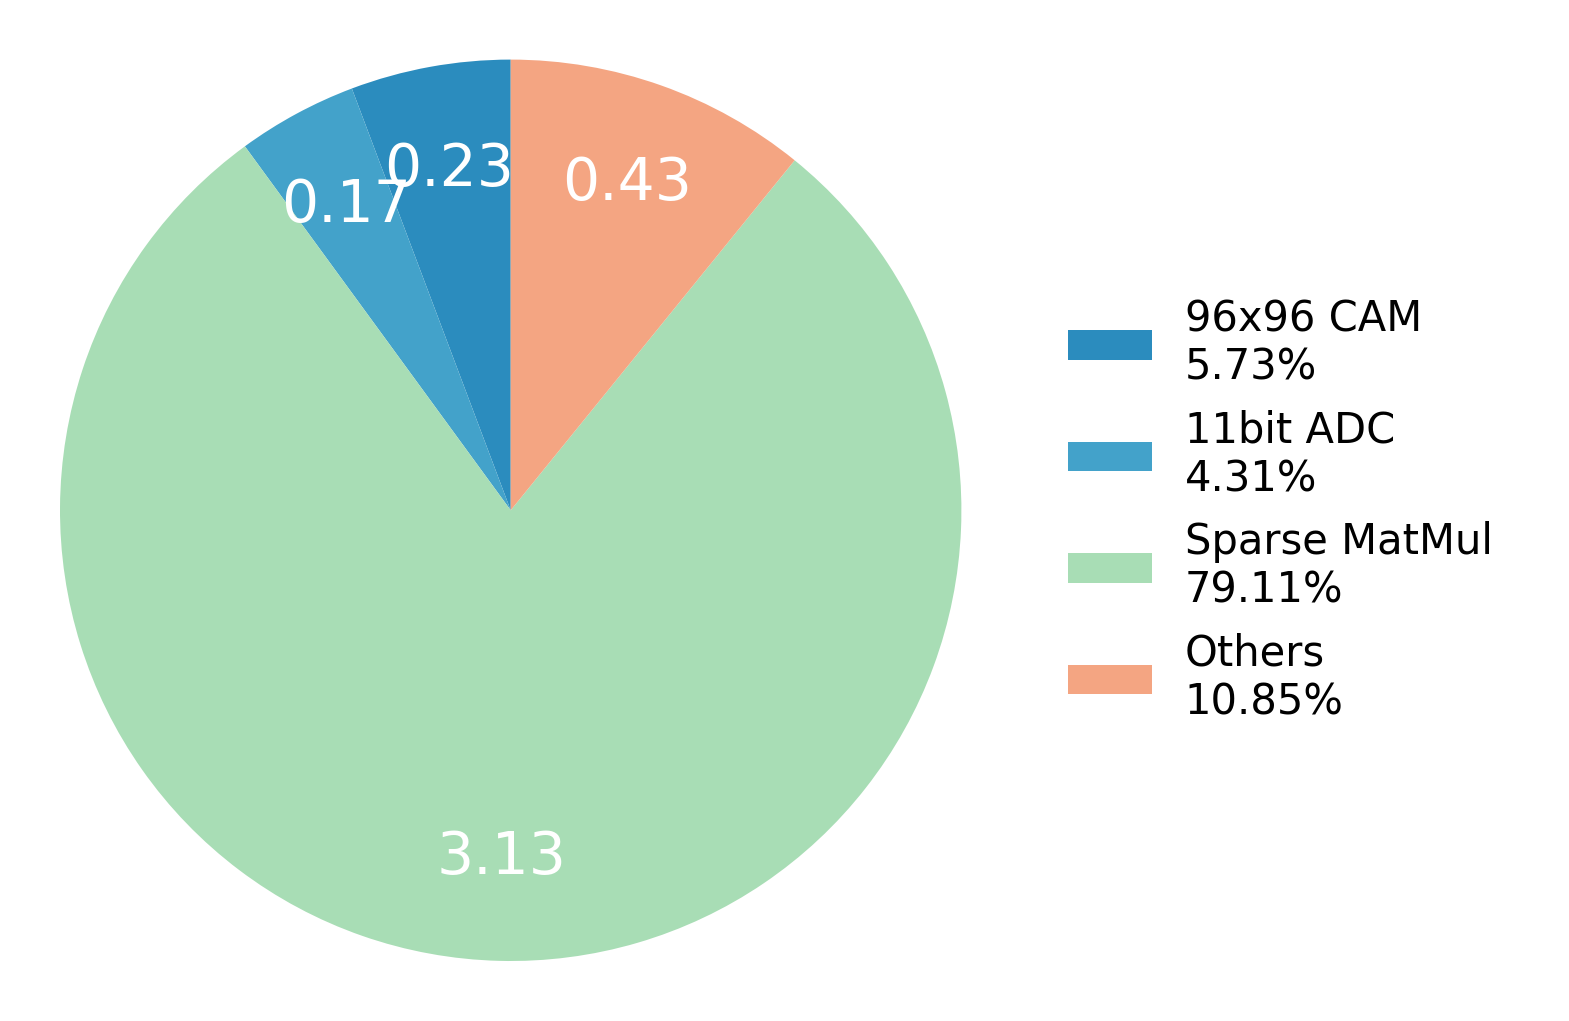

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

input_df = df96
input_df = input_df.fillna(0)
area_values = input_df['Area mm2.1'].tolist() # in mm2
power_values = input_df['Power W.1'].tolist() # in W
labels = input_df['Module'].tolist()
# Calculate percentages correctly
area_percentages = (input_df['Area mm2.1'] / input_df['Area mm2.1'].sum()).tolist() # No need for tolist() here
power_percentages = (input_df['Power W.1'] / input_df['Power W.1'].sum()).tolist() # No need for tolist() here
def process_module_data(input_df, threshold=4, area_col='Area mm2.1', power_col='Power W.1', module_col='Module'):
    """
    Process module data to combine values below threshold into 'Others' category, separately for area and power

    Args:
        input_df (pd.DataFrame): Input DataFrame containing module data
        threshold (float): Threshold percentage (0-100) below which values are combined into 'Others'
        area_col (str): Name of the area column
        power_col (str): Name of the power column
        module_col (str): Name of the module label column

    Returns:
        tuple: (area_values, power_values, labels_area, labels_power, area_percentages, power_percentages)
    """
    # Fill NaN values with 0
    input_df = input_df.fillna(0)

    # Initialize new lists for area
    new_labels_area = []
    new_area_values = []

    # Initialize new lists for power
    new_labels_power = []
    new_power_values = []

    # Calculate initial percentages
    area_percentages = input_df[area_col] / input_df[area_col].sum() * 100
    power_percentages = input_df[power_col] / input_df[power_col].sum() * 100

    # Process area values
    others_area = 0
    for index, row in input_df.iterrows():
        if area_percentages[index] >= threshold:
            new_labels_area.append(row[module_col])
            new_area_values.append(row[area_col])
        else:
            others_area += row[area_col]

    # Add Others category for area if needed
    if others_area > 0:
        new_labels_area.append("Others")
        new_area_values.append(others_area)

    # Process power values
    others_power = 0
    for index, row in input_df.iterrows():
        if power_percentages[index] >= threshold:
            new_labels_power.append(row[module_col])
            new_power_values.append(row[power_col])
        else:
            others_power += row[power_col]

    # Add Others category for power if needed
    if others_power > 0:
        new_labels_power.append("Others")
        new_power_values.append(others_power)

    # Calculate final percentages
    new_area_percentages = [value/sum(new_area_values)*100 for value in new_area_values]
    new_power_percentages = [value/sum(new_power_values)*100 for value in new_power_values]

    return new_area_values, new_power_values, new_labels_area, new_labels_power, new_area_percentages, new_power_percentages

# Example usage:
area_values, power_values, labels_area, labels_power, area_percentages, power_percentages = process_module_data(df96)

# Create separate legend labels for area and power
legend_labels_area = [f'{labels_area[i]}\n{area_percentages[i]:.2f}%' for i in range(len(labels_area))]
legend_labels_power = [f'{labels_power[i]}\n{power_percentages[i]:.2f}%' for i in range(len(labels_power))]


print(labels)
# Print results to verify
print("\nArea Labels:", labels_area)
print("Area Percentages:", [f"{x:.2f}%" for x in area_percentages])
print("\nPower Labels:", labels_power)
print("Power Percentages:", [f"{x:.2f}%" for x in power_percentages])

print(area_values)
print(power_values)
print(labels_area)
print(area_percentages)
print(power_percentages)

# Area Plot
fig1, ax1 = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)
wedges1, texts1, autotexts1 = ax1.pie(area_values,
                                     colors=['#2b8cbe', '#43a2ca', '#a8ddb5', '#f4a582', '#92c5de'],
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

# Add title
# ax1.set_title('(a) Area', pad=20, fontsize=7)

# Add value labels inside the pie slices
for i, wedge in enumerate(wedges1):
    x, y = wedge.center
    angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
    x = x + 1 * np.cos(angle)
    y = y + 1 * np.sin(angle)
    ax1.text(x, y, f'{area_values[i]:.3f}', ha='center', va='center', color='white', fontsize=7)



# Create legend with vertical stacking
legend_labels = [f'{labels[i]}\n{area_percentages[i]:.2f}%' for i in range(len(labels_area))]
ax1.legend(wedges1, legend_labels_area,
          loc='center left',
          bbox_to_anchor=(1.1, 0.5),
          frameon=False,
          fontsize=5,
          ncol=1)  # This ensures vertical stacking

plt.tight_layout()
plt.show()




# Power Plot
fig2, ax2 = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)
wedges2, texts2, autotexts2 = ax2.pie(power_values,
                                     colors=['#2b8cbe', '#43a2ca', '#a8ddb5', '#f4a582', '#92c5de'],
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

# Add title
# ax2.set_title('(b) Power', pad=20, fontsize=7)

# Add value labels inside the pie slices
for i, wedge in enumerate(wedges2):
    x, y = wedge.center
    angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
    x = x + 1 * np.cos(angle)
    y = y + 1 * np.sin(angle)
    ax2.text(x, y, f'{power_values[i]:.2f}', ha='center', va='center', color='white', fontsize=7)

# Create legend with vertical stacking
legend_labels = [f'{labels[i]}\n{power_percentages[i]:.2f}%' for i in range(len(labels_power))]
ax2.legend(wedges2, legend_labels_power,
          loc='center left',
          bbox_to_anchor=(1.1, 0.5),
          frameon=False,
          fontsize=5,
          ncol=1)  # This ensures vertical stacking

plt.tight_layout()
plt.show()

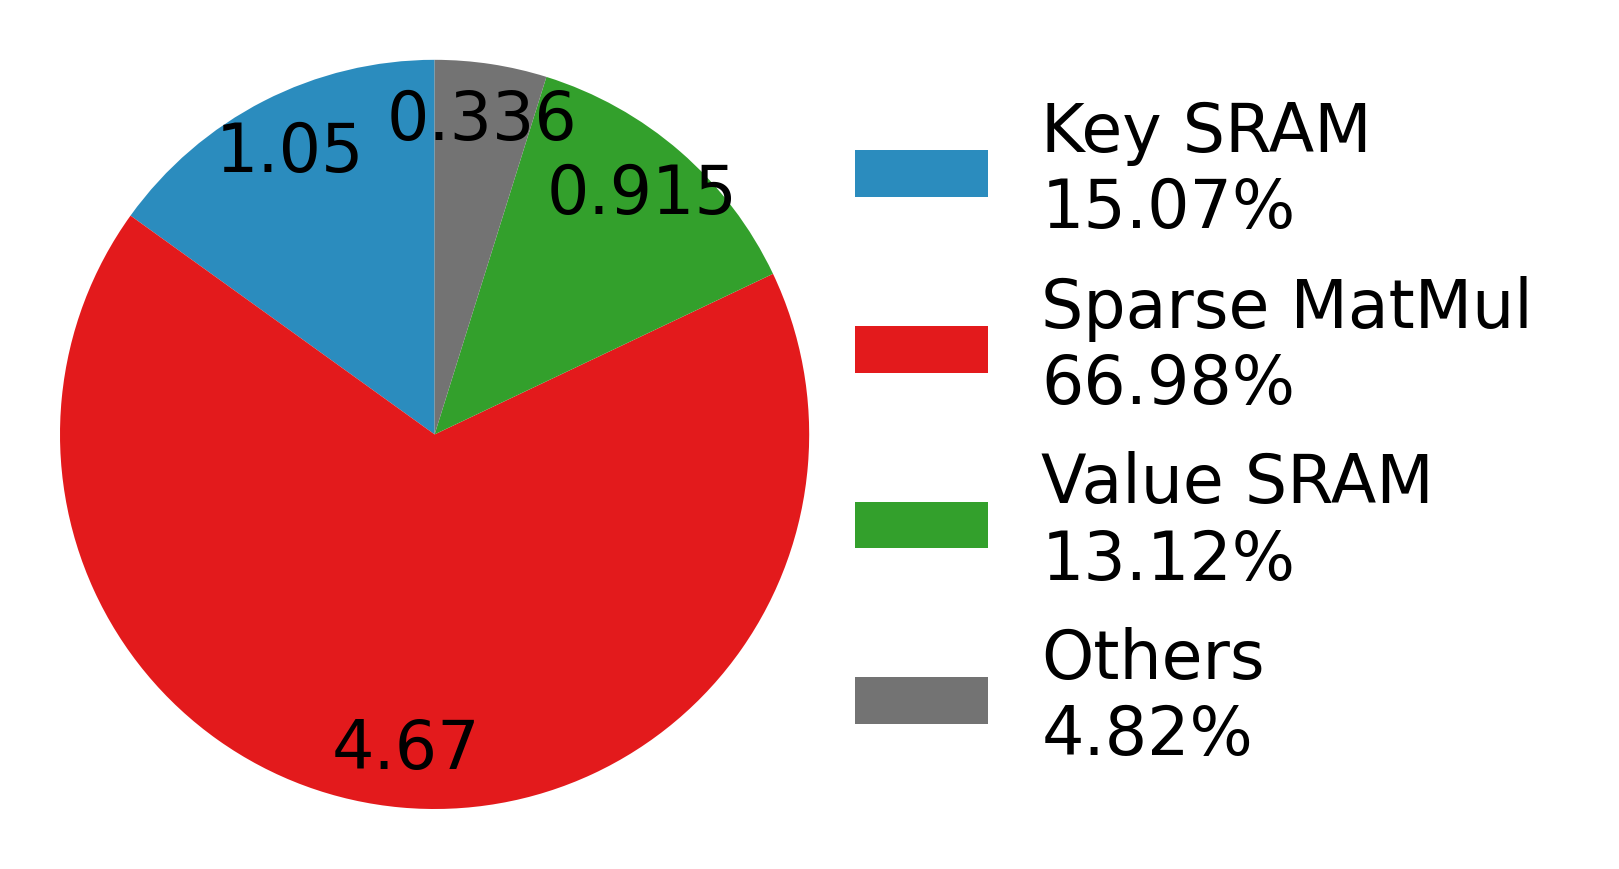

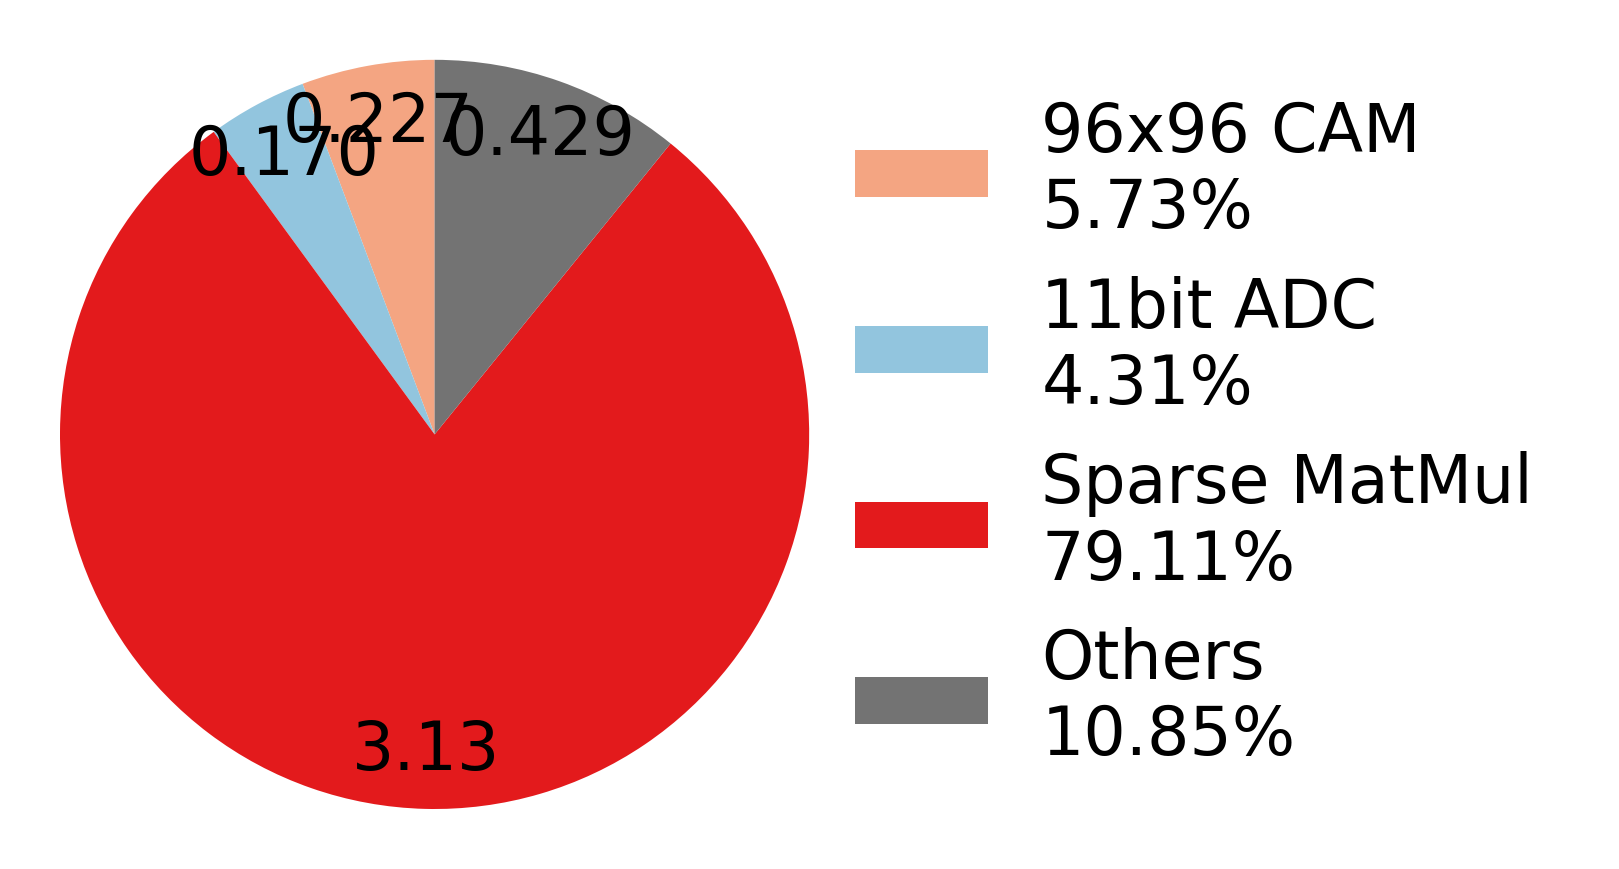

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Color mapping dictionary
color_mapping = {
    'Key SRAM': '#2b8cbe',
    'Sparse MatMul': '#e31a1c',
    'Value SRAM': '#33a02c',
    '96x96 CAM': '#f4a582',
    '11bit ADC': '#92c5de',

    'Q buffer': '#7fcdbb',
    'ML_REG': '#41b6c4',
    'CAMH subtractor': '#1d91c0',
    'ACCUM array': '#225ea8',
    'Top3': '#253494',
    'Convert': '#2c7fb8',
    'Top30': '#31a354',
    'SoftMax': '#756bb1',
    'FP32 Accum': '#636363',
    '96x1 buf': '#969696',
    'x8': '#bdbdbd',
    'Others': '#737373'
}

def process_module_data(input_df, threshold=4, area_col='Area mm2.1', power_col='Power W.1', module_col='Module'):
    input_df = input_df.fillna(0)
    new_labels_area = []
    new_area_values = []
    new_labels_power = []
    new_power_values = []

    area_percentages = input_df[area_col] / input_df[area_col].sum() * 100
    power_percentages = input_df[power_col] / input_df[power_col].sum() * 100

    others_area = 0
    others_power = 0

    for index, row in input_df.iterrows():
        if area_percentages[index] >= threshold:
            new_labels_area.append(row[module_col])
            new_area_values.append(row[area_col])
        else:
            others_area += row[area_col]

        if power_percentages[index] >= threshold:
            new_labels_power.append(row[module_col])
            new_power_values.append(row[power_col])
        else:
            others_power += row[power_col]

    if others_area > 0:
        new_labels_area.append("Others")
        new_area_values.append(others_area)
    if others_power > 0:
        new_labels_power.append("Others")
        new_power_values.append(others_power)

    new_area_percentages = [value/sum(new_area_values)*100 for value in new_area_values]
    new_power_percentages = [value/sum(new_power_values)*100 for value in new_power_values]

    return new_area_values, new_power_values, new_labels_area, new_labels_power, new_area_percentages, new_power_percentages

def create_pie_chart(values, labels, percentages, title, fig_size=(2.5, 1.8)):
    fig, ax = plt.subplots(figsize=fig_size, dpi=600)

    # Map colors to labels using the color dictionary
    colors = [color_mapping[label] for label in labels]

    wedges, texts, autotexts = ax.pie(values,
                                     colors=colors,
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

    # ax.set_title(title, pad=20, fontsize=7)

    # Add value labels inside pie slices
    for i, wedge in enumerate(wedges):
        x, y = wedge.center
        angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
        x = x + 1.1 * np.cos(angle)
        y = y + 1.1 * np.sin(angle)
        value_text = f'{values[i]:.2f}' if values[i] >= 1 else f'{values[i]:.3f}'
        ax.text(x, y, value_text, ha='center', va='center', color='black', fontsize=8)

    # Create legend
    legend_labels = [f'{labels[i]}\n{percentages[i]:.2f}%' for i in range(len(labels))]
    ax.legend(wedges, legend_labels,
             loc='center left',
             bbox_to_anchor=(1.0, 0.5),
             frameon=False,
             fontsize=8,
             ncol=1)

    plt.tight_layout()
    return fig, ax

# Process data and create charts
area_values, power_values, labels_area, labels_power, area_percentages, power_percentages = process_module_data(df96)

# Create area pie chart
create_pie_chart(area_values, labels_area, area_percentages, '(a) Area')
plt.show()

# Create power pie chart
create_pie_chart(power_values, labels_power, power_percentages, '(b) Power')
plt.show()

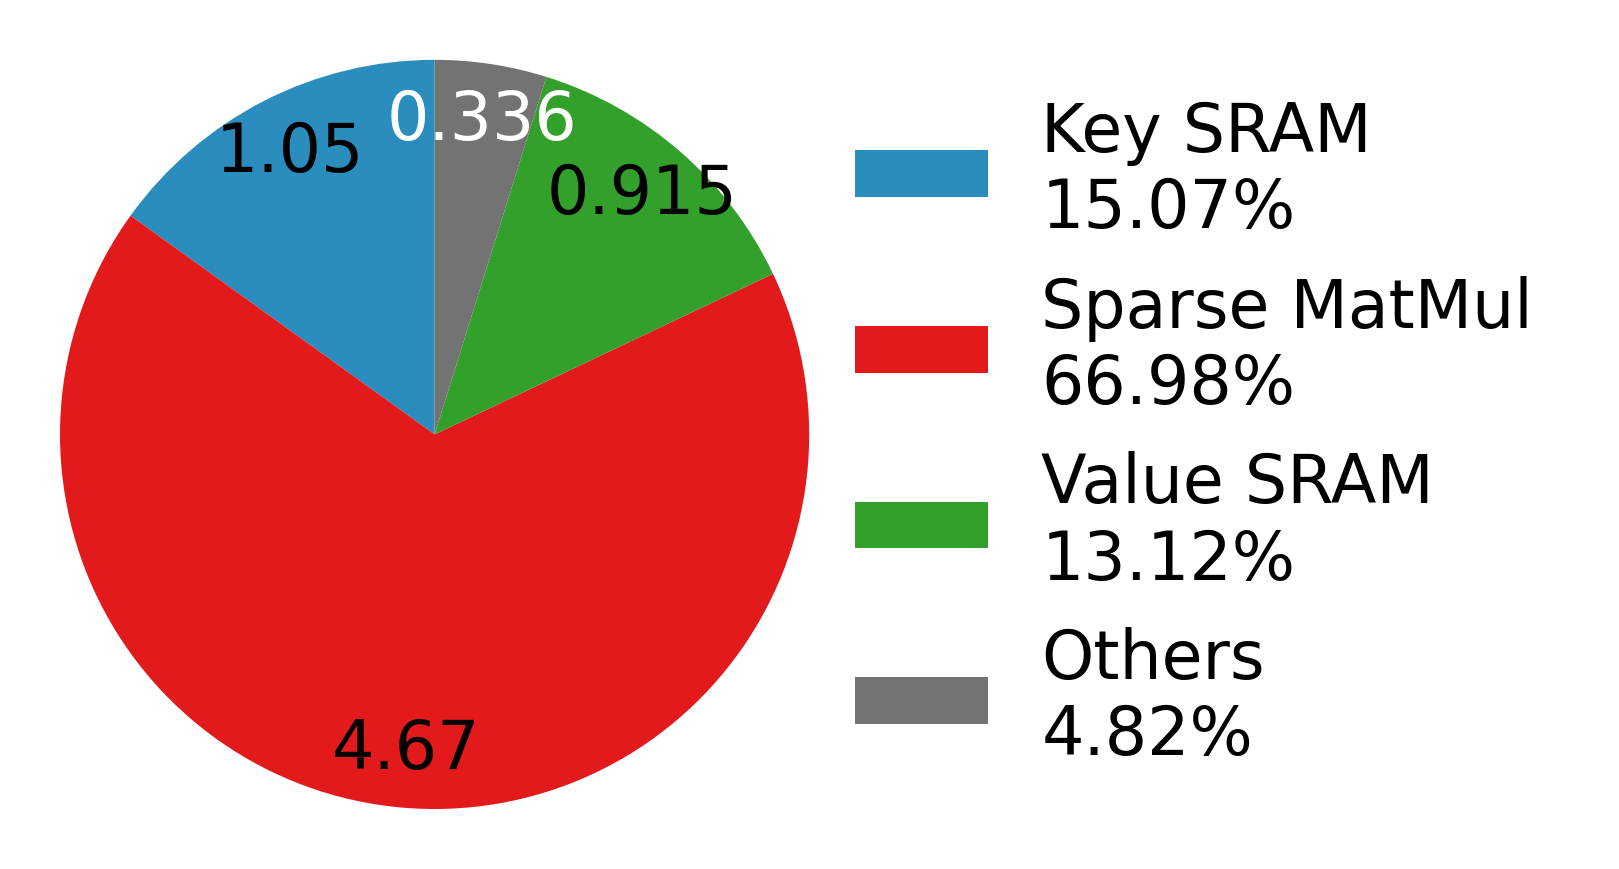

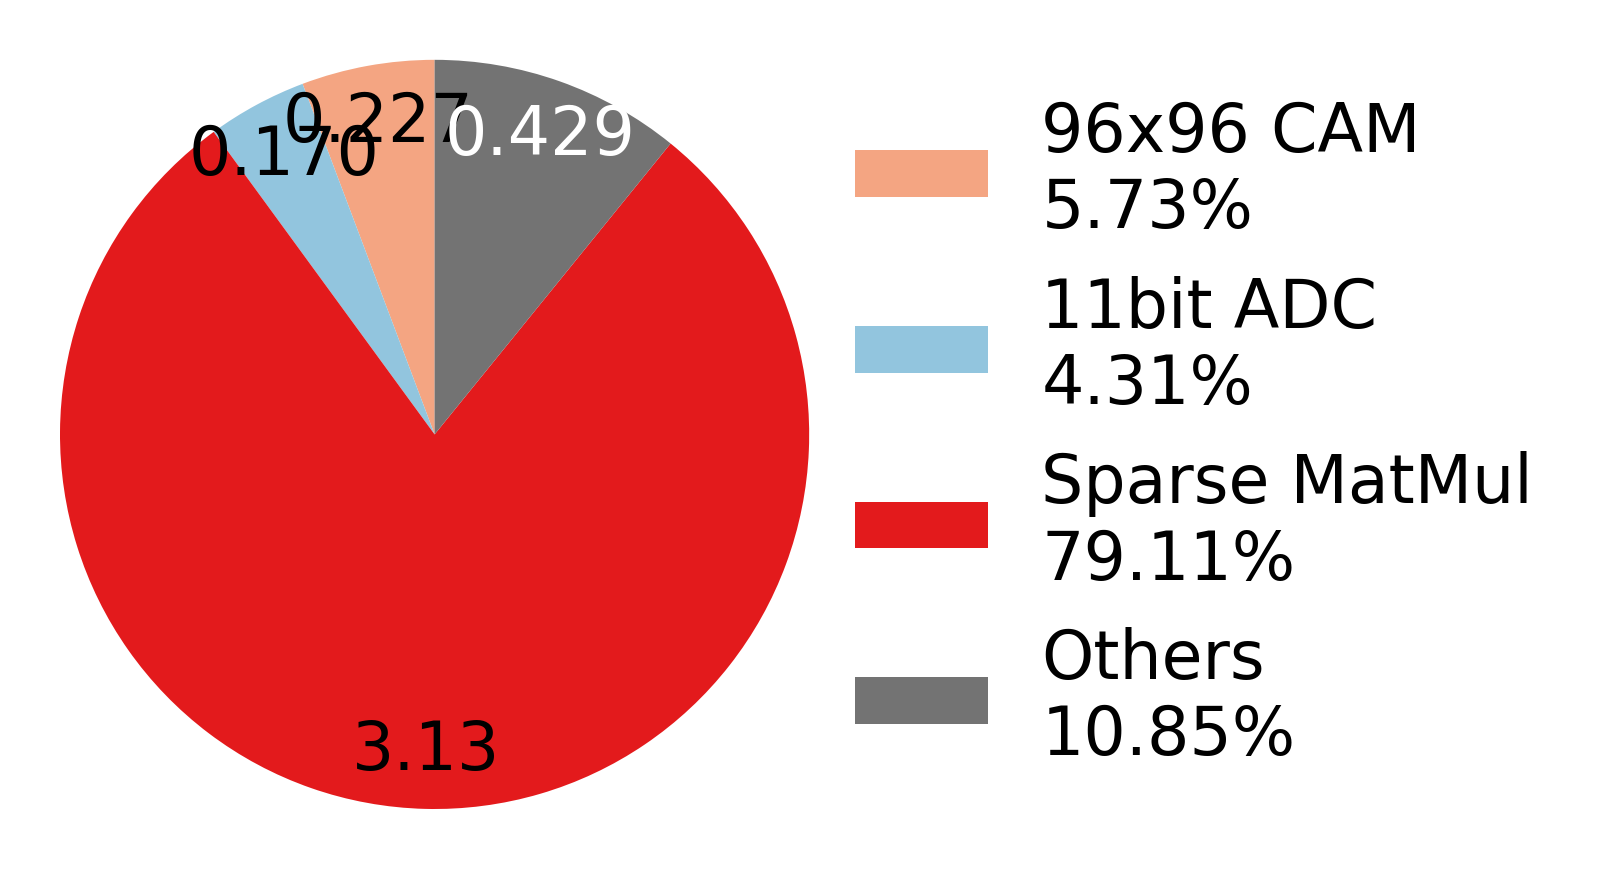

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import rgb_to_hsv, hex2color

# Color mapping dictionary
color_mapping = {
    'Key SRAM': '#2b8cbe',
    'Sparse MatMul': '#e31a1c',
    'Value SRAM': '#33a02c',
    '96x96 CAM': '#f4a582',
    '11bit ADC': '#92c5de',
    'Q buffer': '#7fcdbb',
    'ML_REG': '#41b6c4',
    'CAMH subtractor': '#1d91c0',
    'ACCUM array': '#225ea8',
    'Top3': '#253494',
    'Convert': '#2c7fb8',
    'Top30': '#31a354',
    'SoftMax': '#756bb1',
    'FP32 Accum': '#636363',
    '96x1 buf': '#969696',
    'x8': '#bdbdbd',
    'Others': '#737373'
}

def get_text_color(hex_color):
    """Determine if text should be white or black based on background brightness"""
    rgb = hex2color(hex_color)
    hsv = rgb_to_hsv(rgb)
    # Use value (brightness) from HSV to determine text color
    return 'white' if hsv[2] < 0.6 else 'black'

def process_module_data(input_df, threshold=4, area_col='Area mm2.1', power_col='Power W.1', module_col='Module'):
    input_df = input_df.fillna(0)
    new_labels_area = []
    new_area_values = []
    new_labels_power = []
    new_power_values = []

    area_percentages = input_df[area_col] / input_df[area_col].sum() * 100
    power_percentages = input_df[power_col] / input_df[power_col].sum() * 100

    others_area = 0
    others_power = 0

    for index, row in input_df.iterrows():
        if area_percentages[index] >= threshold:
            new_labels_area.append(row[module_col])
            new_area_values.append(row[area_col])
        else:
            others_area += row[area_col]

        if power_percentages[index] >= threshold:
            new_labels_power.append(row[module_col])
            new_power_values.append(row[power_col])
        else:
            others_power += row[power_col]

    if others_area > 0:
        new_labels_area.append("Others")
        new_area_values.append(others_area)
    if others_power > 0:
        new_labels_power.append("Others")
        new_power_values.append(others_power)

    new_area_percentages = [value/sum(new_area_values)*100 for value in new_area_values]
    new_power_percentages = [value/sum(new_power_values)*100 for value in new_power_values]

    return new_area_values, new_power_values, new_labels_area, new_labels_power, new_area_percentages, new_power_percentages

def create_pie_chart(values, labels, percentages, title, fig_size=(2.5, 1.8)):
    fig, ax = plt.subplots(figsize=fig_size, dpi=600)

    # Map colors to labels using the color dictionary
    colors = [color_mapping[label] for label in labels]

    wedges, texts, autotexts = ax.pie(values,
                                     colors=colors,
                                     autopct='',
                                     startangle=90,
                                     radius=1.3)

    # Add value labels inside pie slices with appropriate text color
    for i, wedge in enumerate(wedges):
        x, y = wedge.center
        angle = np.pi/180 * (wedge.theta1 + wedge.theta2) / 2
        x = x + 1.1 * np.cos(angle)
        y = y + 1.1 * np.sin(angle)
        value_text = f'{values[i]:.2f}' if values[i] >= 1 else f'{values[i]:.3f}'
        text_color = get_text_color(color_mapping[labels[i]])
        ax.text(x, y, value_text, ha='center', va='center', color=text_color, fontsize=8)

    # Create legend
    legend_labels = [f'{labels[i]}\n{percentages[i]:.2f}%' for i in range(len(labels))]
    ax.legend(wedges, legend_labels,
             loc='center left',
             bbox_to_anchor=(1.0, 0.5),
             frameon=False,
             fontsize=8,
             ncol=1)

    plt.tight_layout()
    return fig, ax

# Process data and create charts
area_values, power_values, labels_area, labels_power, area_percentages, power_percentages = process_module_data(df96)

# Create area pie chart
create_pie_chart(area_values, labels_area, area_percentages, '(a) Area')
plt.show()

# Create power pie chart
create_pie_chart(power_values, labels_power, power_percentages, '(b) Power')
plt.show()

In [ ]:
df_titanxp

,model,latency(ms),dynamic power(Watts),energy(Joules)
0,google/vit-base-patch16-224,4.226558,194.949875,0.823967
1,bert-base-cola,14.287604,185.384500,2.648700
2,gpt2-small-1bw,12.681725,181.739200,2.304767
3,gpt2-small-ptb,12.715310,181.573525,2.308764
4,gpt2-small-wikitext103,12.719091,181.524625,2.308828
5,gpt2-small-wikitext2,13.028105,237.909825,3.099514
6,gpt2-medium-1bw,44.575253,177.472750,7.910893
7,gpt2-medium-ptb,44.665835,176.477875,7.882532
8,gpt2-medium-wikitext103,44.660392,176.655675,7.889512
9,gpt2-medium-wikitext2,44.667361,176.465750,7.882259


In [ ]:
df_spatten_speedup

,Model,Over TITAN Xp GPU,Over Xeon CPU,Over Nano GPU,Over Raspberry Pi CPU
0,bert-base-squad-v1,88,165,623,2117
1,bert-base-squad-v2,72,143,524,1526
2,bert-large-squad-v1,68,136,427,2089
3,bert-large-squad-v2,59,108,399,1569
4,bert-base-cola,957,1308,4506,6014
5,bert-base-mnli-mm,159,269,779,2500
6,bert-base-mnli-m,152,255,678,2160
7,bert-base-mrpc,101,206,555,3521
8,bert-base-qnli,148,265,770,4342
9,bert-base-qqp,231,436,1133,2989


# Gateway combination

In [ ]:
# First, let's check for duplicates in each dataframe
print("Checking for duplicate model names:")
print("\nDuplicates in df_model_dims:")
print(df_model_dims['model'][df_finder(sizing_choice = 96, core_num = 2)['model'].duplicated()])
print("\nDuplicates in df_A100:")
print(df_A100['model'][df_A100['model'].duplicated()])
print("\nDuplicates in df_L40:")
print(df_L40['model'][df_L40['model'].duplicated()])
print("\nDuplicates in df_titanxp:")
print(df_titanxp['model'][df_titanxp['model'].duplicated()])

# Create mapping dictionaries instead of using map function
def create_metric_dict(df, model_col, metric_col):
    # If there are duplicates, we'll take the first occurrence
    return df.drop_duplicates(subset=[model_col]).set_index(model_col)[metric_col].to_dict()

# Create mapping dictionaries for each metric
latency_camformer = create_metric_dict(df_model_dims, 'model', 'latency via CAMformer')
power_camformer = create_metric_dict(df_model_dims, 'model', 'power via CAMformer')
energy_camformer = create_metric_dict(df_model_dims, 'model', 'energy via CAMformer')

latency_a100 = create_metric_dict(df_A100_metrics, 'model', 'latency(s)')
power_a100 = create_metric_dict(df_A100_metrics, 'model', 'dynamic power(Watts)')
energy_a100 = create_metric_dict(df_A100_metrics, 'model', 'energy(Joules)')

latency_l40 = create_metric_dict(df_L40_metrics, 'model', 'latency(s)')
power_l40 = create_metric_dict(df_L40_metrics, 'model', 'dynamic power(Watts)')
energy_l40 = create_metric_dict(df_L40_metrics, 'model', 'energy(Joules)')

latency_titanxp = create_metric_dict(df_titanxp_metrics, 'model', 'latency(s)')
power_titanxp = create_metric_dict(df_titanxp_metrics, 'model', 'dynamic power(Watts)')
energy_titanxp = create_metric_dict(df_titanxp_metrics, 'model', 'energy(Joules)')

# Find common models across all dictionaries
common_models = set(latency_camformer.keys()) & set(latency_a100.keys()) & \
                set(latency_l40.keys()) & set(latency_titanxp.keys())

# Create the comparison dataframes
df_all_devices_latency = pd.DataFrame({
    'model': list(common_models),
    'latency via CAMformer': [latency_camformer[model] for model in common_models],
    'A100': [latency_a100[model] for model in common_models],
    'L40': [latency_l40[model] for model in common_models],
    'TITANXp': [latency_titanxp[model] for model in common_models]
})

df_all_devices_power = pd.DataFrame({
    'model': list(common_models),
    'power via CAMformer': [power_camformer[model] for model in common_models],
    'A100': [power_a100[model] for model in common_models],
    'L40': [power_l40[model] for model in common_models],
    'TITANXp': [power_titanxp[model] for model in common_models]
})

df_all_devices_energy = pd.DataFrame({
    'model': list(common_models),
    'energy via CAMformer': [energy_camformer[model] for model in common_models],
    'A100': [energy_a100[model] for model in common_models],
    'L40': [energy_l40[model] for model in common_models],
    'TITANXp': [energy_titanxp[model] for model in common_models]
})

# Sort all dataframes by model name for consistency
df_all_devices_latency = df_all_devices_latency.sort_values('model').reset_index(drop=True)
df_all_devices_power = df_all_devices_power.sort_values('model').reset_index(drop=True)
df_all_devices_energy = df_all_devices_energy.sort_values('model').reset_index(drop=True)

# Display all three dataframes
print("\nLatency Comparison (ms):")
print(df_all_devices_latency)
print("\nPower Comparison (Watts):")
print(df_all_devices_power)
print("\nEnergy Comparison (Joules):")
print(df_all_devices_energy)

Checking for duplicate model names:

Duplicates in df_model_dims:
Series([], Name: model, dtype: object)

Duplicates in df_A100:
Series([], Name: model, dtype: object)

Duplicates in df_L40:
Series([], Name: model, dtype: object)

Duplicates in df_titanxp:
20                 bert-base-cola
21    google/vit-base-patch16-224
Name: model, dtype: object

Latency Comparison (ms):
                          model  latency via CAMformer      A100       L40  \
0                bert-base-cola               0.026133  0.008553  0.010022   
1              bert-base-mnli-m               0.026133  0.008554  0.010144   
2             bert-base-mnli-mm               0.026133  0.008557  0.010059   
3                bert-base-mrpc               0.026133  0.008559  0.010104   
4                bert-base-qnli               0.026133  0.008554  0.010028   
5                 bert-base-qqp               0.026133  0.008555  0.010106   
6                 bert-base-rte               0.026133  0.008553  0.010034  

In [ ]:
# Calculate speedups over each device
df_speedups = pd.DataFrame()
df_speedups['model'] = df_all_devices_latency[~df_all_devices_latency['model'].str.contains('gpt2-small')]['model']

# CAMformer speedup over each device
df_speedups['CAMformer_over_A100'] = df_all_devices_latency['A100'] / df_all_devices_latency['latency via CAMformer']
df_speedups['CAMformer_over_L40'] = df_all_devices_latency['L40'] / df_all_devices_latency['latency via CAMformer']
df_speedups['CAMformer_over_TITANXp'] = df_all_devices_latency['TITANXp'] / df_all_devices_latency['latency via CAMformer']

df_speedups

,model,CAMformer_over_A100,CAMformer_over_L40,CAMformer_over_TITANXp
0,bert-base-cola,0.327276,0.383486,0.546723
1,bert-base-mnli-m,0.327319,0.388148,0.546790
2,bert-base-mnli-mm,0.327434,0.384919,0.564108
3,bert-base-mrpc,0.327526,0.386650,0.555407
4,bert-base-qnli,0.327327,0.383725,0.556539
5,bert-base-qqp,0.327358,0.386698,0.535367
6,bert-base-rte,0.327272,0.383943,0.557806
7,bert-base-squad-v2,0.327225,0.384593,0.548949
8,bert-base-sst2,0.327276,0.382457,0.556885
9,bert-large-squad-v2,0.544228,0.558063,0.800389


In [ ]:
# Calculate energy speedups over each device
df_energy_speedups = pd.DataFrame()
df_energy_speedups['model'] = df_all_devices_energy[~df_all_devices_energy['model'].str.contains('gpt2-small')]['model']

df_energy_speedups['CAMformer_over_A100'] = df_all_devices_energy['A100'] / df_all_devices_energy['energy via CAMformer']
df_energy_speedups['CAMformer_over_L40'] = df_all_devices_energy['L40'] / df_all_devices_energy['energy via CAMformer']
df_energy_speedups['CAMformer_over_TITANXp'] = df_all_devices_energy['TITANXp'] / df_all_devices_energy['energy via CAMformer']

df_energy_speedups = df_energy_speedups[df_energy_speedups['model'] != "google/vit-base-patch16-224"]

df_energy_speedups

,model,CAMformer_over_A100,CAMformer_over_L40,CAMformer_over_TITANXp
0,bert-base-cola,16.761813,21.445504,23.983244
1,bert-base-mnli-m,16.257094,21.511776,31.182781
2,bert-base-mnli-mm,16.122559,21.102520,24.139828
3,bert-base-mrpc,16.384322,20.977773,23.632953
4,bert-base-qnli,15.856486,21.434684,23.508233
5,bert-base-qqp,15.910280,21.494318,30.571035
6,bert-base-rte,16.475648,20.989364,23.390269
7,bert-base-squad-v2,16.117896,21.596800,23.862418
8,bert-base-sst2,16.707240,21.625250,23.349214
9,bert-large-squad-v2,26.949601,30.554848,35.408790


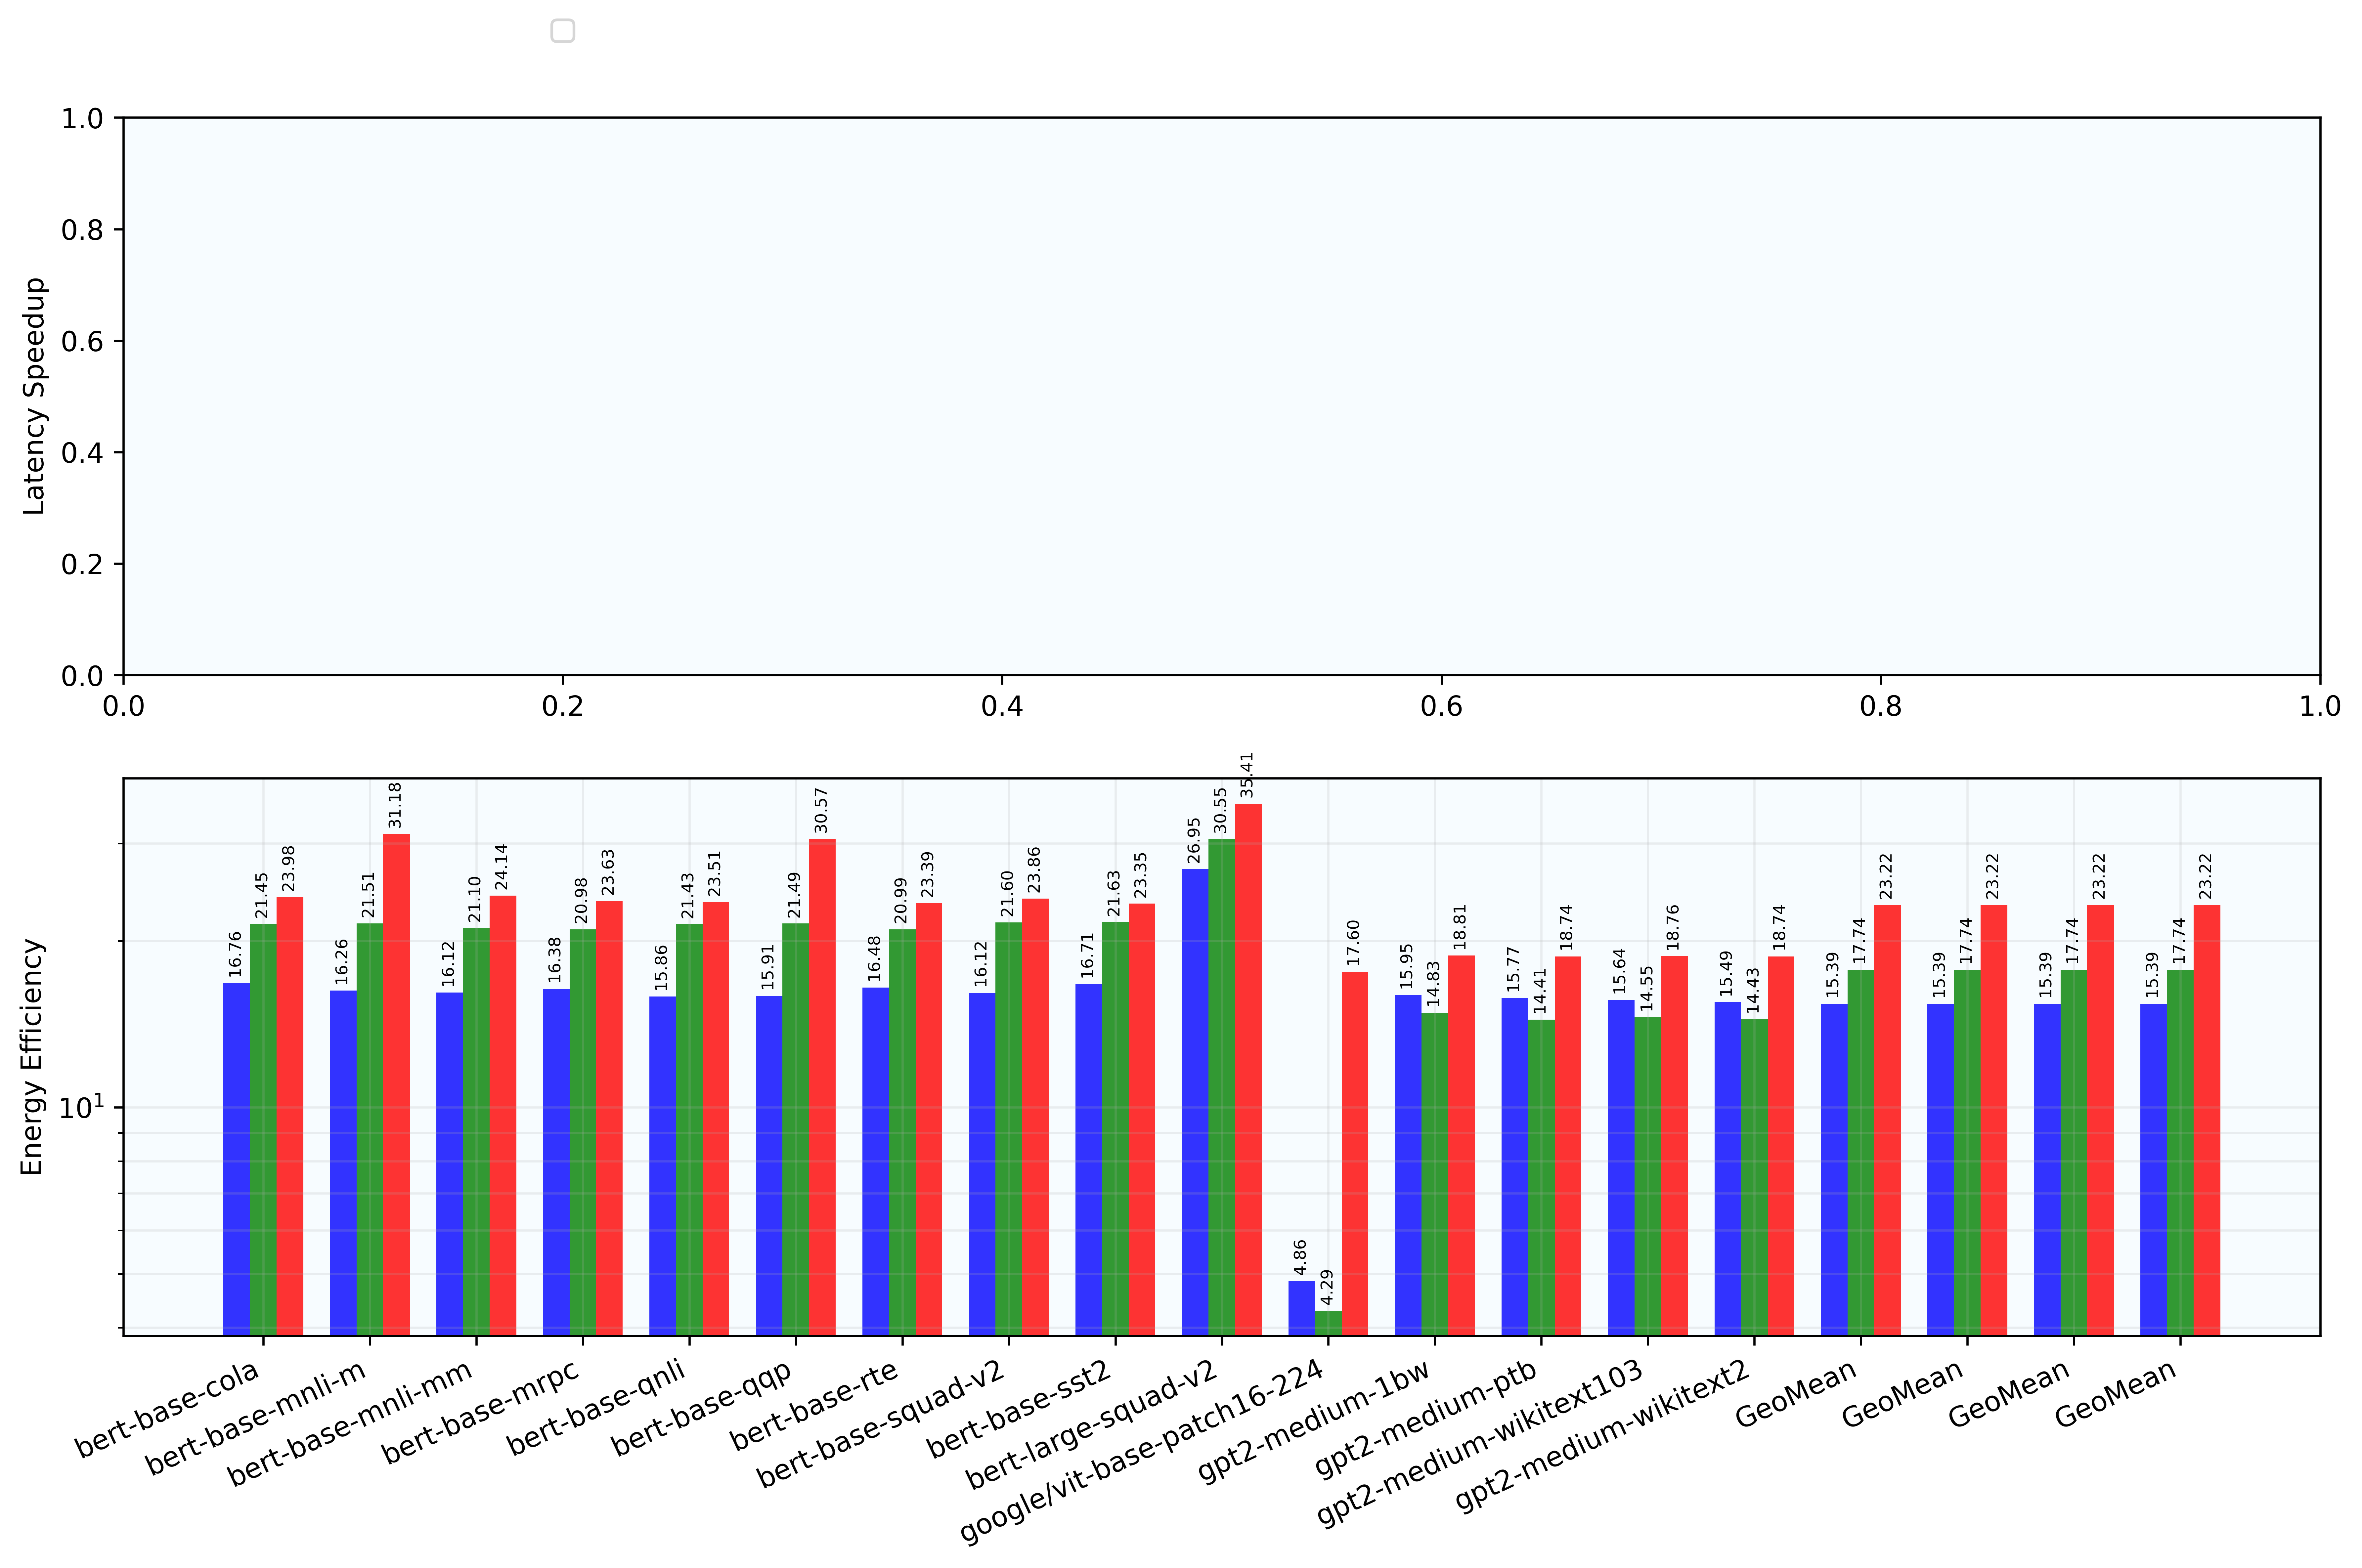

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate geometric mean
def geometric_mean(data):
   return np.exp(np.mean(np.log(data)))

# Add geometric mean to dataframes
for df in [df_speedups, df_energy_speedups]:
   geomean = {
       'model': 'GeoMean',
       'CAMformer_over_A100': geometric_mean(df['CAMformer_over_A100']),
       'CAMformer_over_L40': geometric_mean(df['CAMformer_over_L40']),
       'CAMformer_over_TITANXp': geometric_mean(df['CAMformer_over_TITANXp'])
   }
   df.loc[len(df)] = geomean

blue = "b"
green = "g"
red = "r"

# Plot settings
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), dpi=600)
ax1.set_facecolor('#f7fcff')
ax2.set_facecolor('#f7fcff')
bar_width = 0.25
opacity = 0.8

# Get positions for bars
models = range(len(df_speedups))

# Plot latency speedups
bars1 = ax1.bar(models, df_speedups['CAMformer_over_A100'], bar_width,
       alpha=opacity, color=blue, label='Over A100')
bars2 = ax1.bar([x + bar_width for x in models], df_speedups['CAMformer_over_L40'],
       bar_width, alpha=opacity, color=green, label='Over L40')
bars3 = ax1.bar([x + bar_width*2 for x in models], df_speedups['CAMformer_over_TITANXp'],
       bar_width, alpha=opacity, color=red, label='Over TITANXp')

# Plot energy speedups
bars4 = ax2.bar(models, df_energy_speedups['CAMformer_over_A100'], bar_width,
       alpha=opacity, color=blue)
bars5 = ax2.bar([x + bar_width for x in models], df_energy_speedups['CAMformer_over_L40'],
       bar_width, alpha=opacity, color=green)
bars6 = ax2.bar([x + bar_width*2 for x in models], df_energy_speedups['CAMformer_over_TITANXp'],
       bar_width, alpha=opacity, color=red)

# Add data numbers on top of bars
def add_data_labels(bars, ax):
   for bar in bars:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width() / 2.0, height,
               f' {height:.2f}', ha='center', va='bottom', rotation=90, fontsize = 6)

for bars in [bars1, bars2, bars3]:
   add_data_labels(bars, ax1)

for bars in [bars4, bars5, bars6]:
   add_data_labels(bars, ax2)

# Customize plots
for ax in [ax2]:
   ax.set_yscale('log')
   ax.set_xticks([x + bar_width for x in models])
   ax.set_xticklabels(df_speedups['model'], rotation=25, ha='right')
   ax.grid(True, which="both", ls="-", alpha=0.2)

# Set title and legend
ax1.set_ylabel('Latency Speedup')
ax2.set_ylabel('Energy Efficiency')
ax1.legend(loc='upper center', bbox_to_anchor=(0.2, 1.20), ncol=3)

plt.tight_layout()
plt.show()


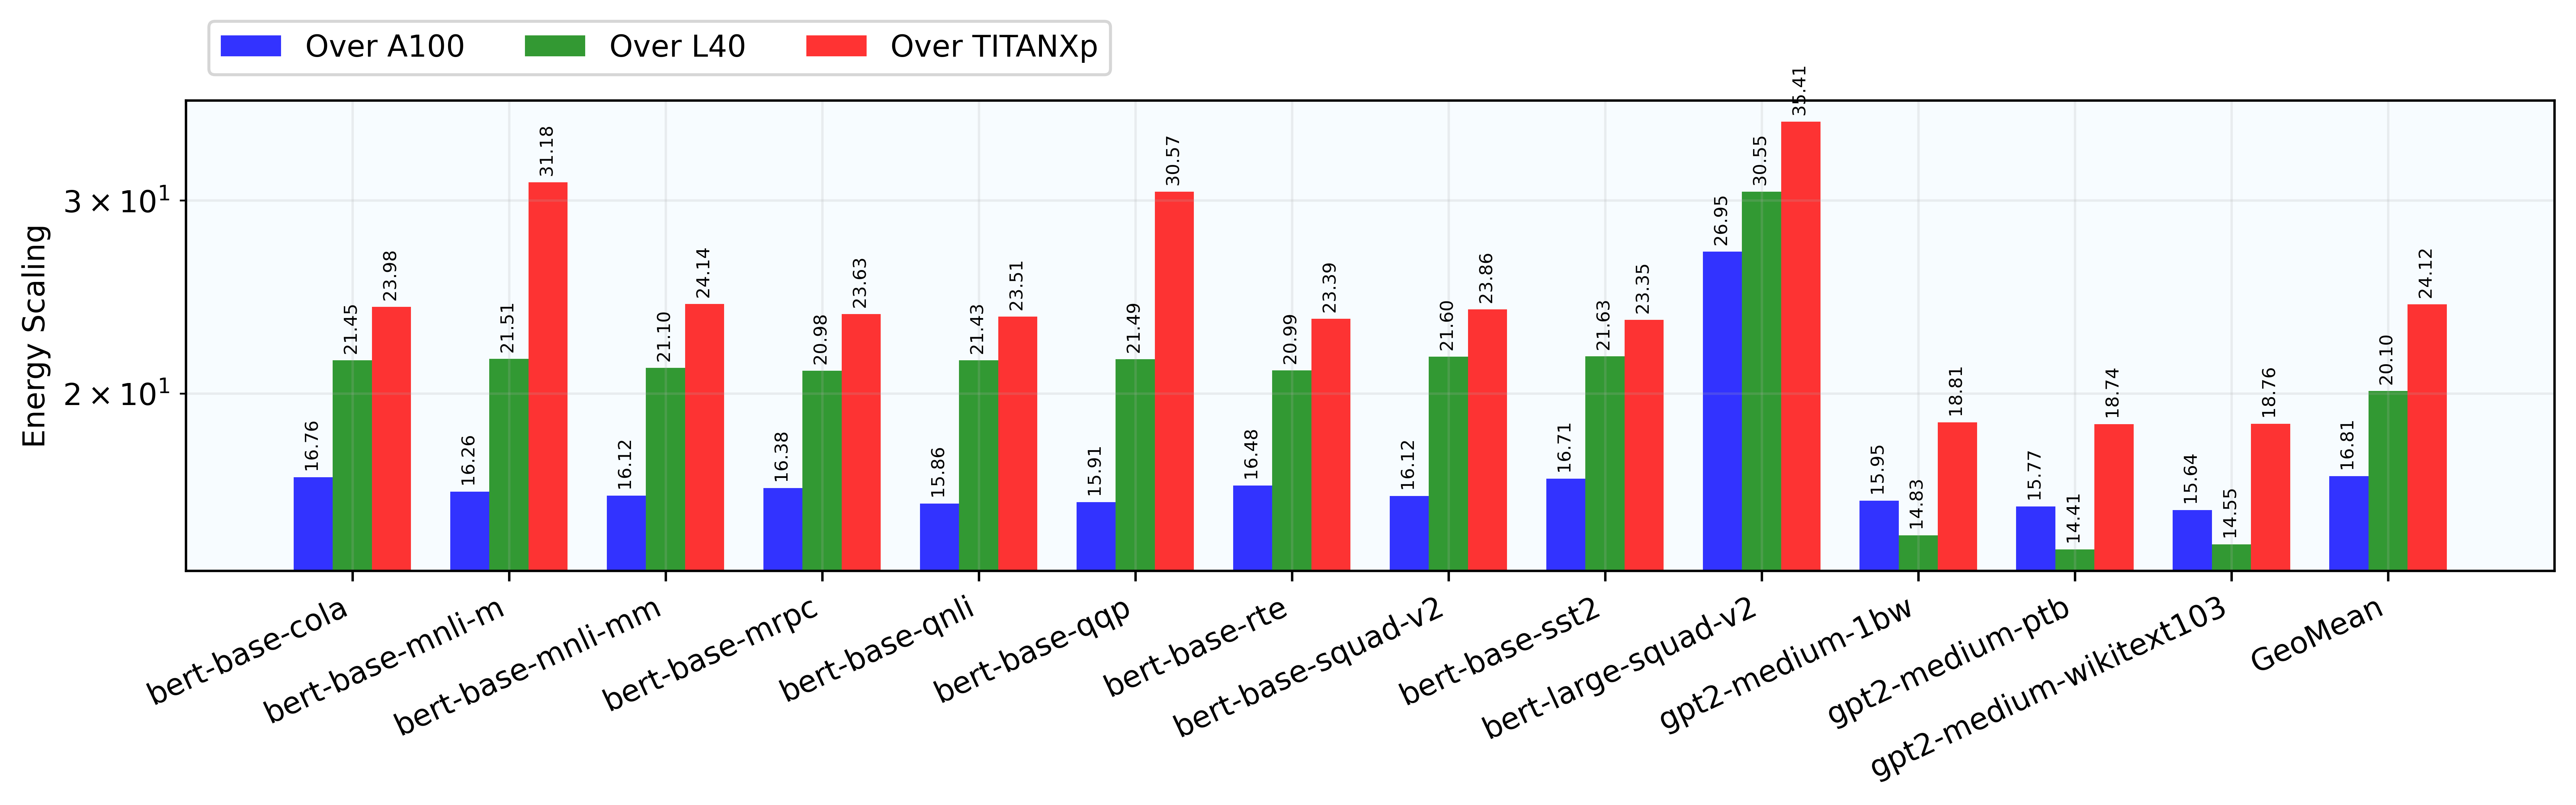

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate geometric mean
def geometric_mean(data):
   return np.exp(np.mean(np.log(data)))

# Add geometric mean to dataframes
for df in [df_speedups, df_energy_speedups]:
   geomean = {
       'model': 'GeoMean',
       'CAMformer_over_A100': geometric_mean(df['CAMformer_over_A100']),
       'CAMformer_over_L40': geometric_mean(df['CAMformer_over_L40']),
       'CAMformer_over_TITANXp': geometric_mean(df['CAMformer_over_TITANXp'])
   }
   df.loc[len(df)] = geomean



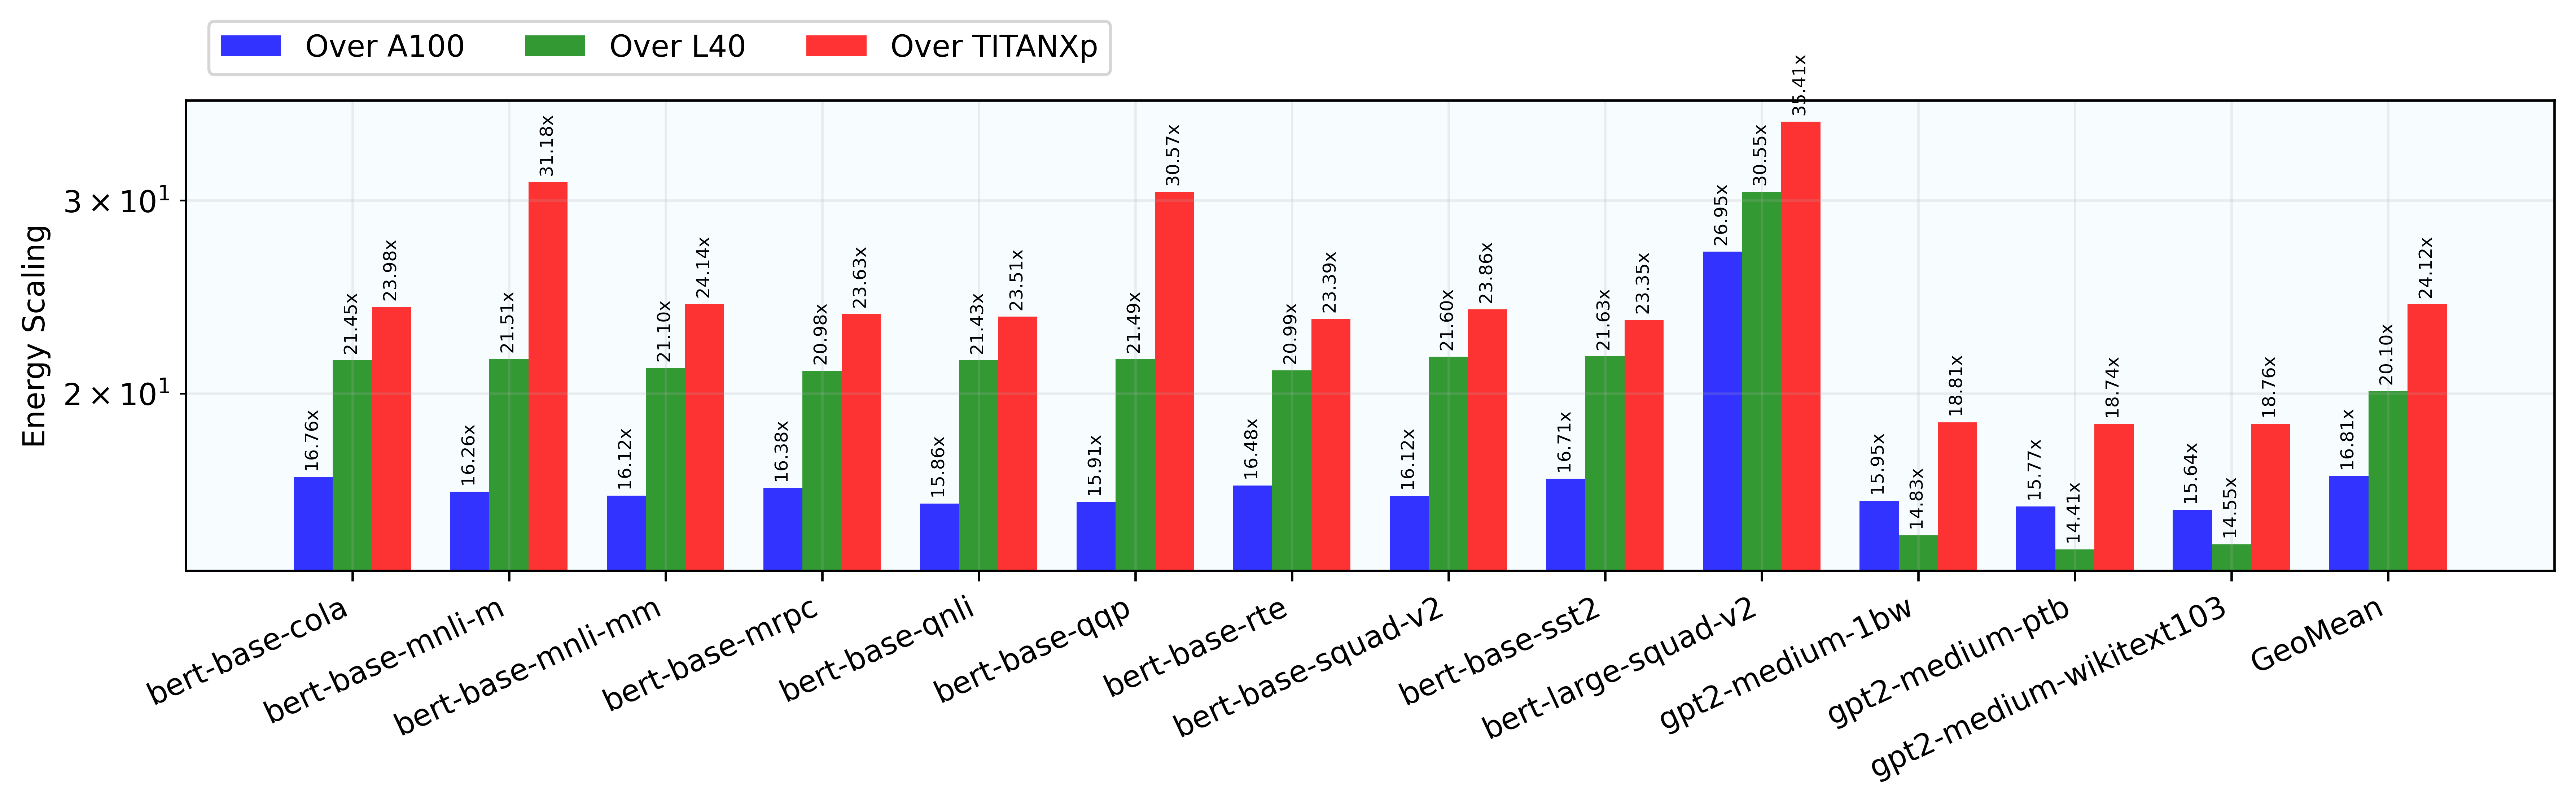

In [ ]:

blue = "b"
green = "g"
red = "r"

# Plot settings
fig, ax2 = plt.subplots(figsize=(12, 4), dpi=600)
ax2.set_facecolor('#f7fcff')
bar_width = 0.25
opacity = 0.8

# Get positions for bars
models = range(len(df_energy_speedups))

# Plot energy speedups
bars4 = ax2.bar(models, df_energy_speedups['CAMformer_over_A100'], bar_width,
       alpha=opacity, color=blue, label='Over A100')
bars5 = ax2.bar([x + bar_width for x in models], df_energy_speedups['CAMformer_over_L40'],
       bar_width, alpha=opacity, color=green, label='Over L40')
bars6 = ax2.bar([x + bar_width*2 for x in models], df_energy_speedups['CAMformer_over_TITANXp'],
       bar_width, alpha=opacity, color=red, label='Over TITANXp')

# Add data numbers on top of bars
def add_data_labels(bars, ax):
   for bar in bars:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width() / 2.0, height,
               f' {height:.2f}x', ha='center', va='bottom', rotation=90, fontsize=6)

for bars in [bars4, bars5, bars6]:
   add_data_labels(bars, ax2)

# Customize plot
ax2.set_yscale('log')
ax2.set_xticks([x + bar_width for x in models])
ax2.set_xticklabels(df_energy_speedups['model'], rotation=25, ha='right')
ax2.grid(True, which="both", ls="-", alpha=0.2)

# Set title and legend
ax2.set_ylabel('Energy Scaling')
ax2.legend(loc='upper center', bbox_to_anchor=(0.2, 1.2), ncol=3)

plt.tight_layout()
plt.show()

In [ ]:
input_df = df32
input_df = input_df.fillna(0)
area_values = input_df['Area mm2.1'].tolist()  # in mm2
power_values = input_df['Power W.1'].tolist()  # in W
labels = input_df['Module'].tolist()

# Calculate percentages correctly
area_percentages =  (input_df['Area mm2.1'] / input_df['Area mm2.1'].sum()).tolist()     # No need for tolist() here
power_percentages = (input_df['Power W.1'] / input_df['Power W.1'].sum()).tolist()   # No need for tolist() here


print(area_values)
print(power_values)
print(labels)
print(area_percentages)
print(power_percentages)

[0.0123904, 1.051, 0.0127808, 0.0033792, 0.000384, 0.008294400064, 0.002534400064, 0.003878400064, 0.01199480014, 0.001430800004, 0.000468000009, 0.008568000093, 0.01746360018, 4.67, 0.915, 0.0, 0.002913600001, 0.002913600001, 0.000716000016]
[0.0232941, 0.0, 0.0240338, 0.0252, 0.0007248, 0.0172928, 0.0075136, 0.0092512, 0.0186348, 0.0007683, 0.0009402, 0.0099705, 0.0249906, 3.13, 0.0, 2e-09, 0.00548, 0.00548, 0.0008784]
['Q buffer', 'Key SRAM', 'ML_REG', '32x32 CAM', '32x1 buf', '9bit ADC', 'x8', '-CAMH subtractor', 'ACCUM array', 'Top3', 'Convert', 'Top30', 'SoftMax', 'Sparse MatMul', 'Value SRAM', 'FP32 Accum', 0, 0, 0]
[0.0018421346066044713, 0.15625673679149174, 0.0019001770709654593, 0.0005024003472557649, 5.709094855179147e-05, 0.0012331644982338538, 0.0003768002699569818, 0.000576618589888252, 0.0017833190564629194, 0.0002127232536881954, 6.957959488556495e-05, 0.0012738418033885611, 0.0025963893213683236, 0.6943091920230889, 0.1360370258460656, 0.0, 0.0004331775722853921, 0.00